## Setup

In [ ]:
# Written by AlchemYst-Crucible, the analysis architecture of AlkhemYst-Ai.
#
# Not written by hand. Every step below corresponds to a component on the
# pipeline canvas, and the settings it runs with are the ones set there.
suppressPackageStartupMessages({
  library(jsonlite)
  library(data.table)
  library(ggplot2)
})

dir.create("artifacts", showWarnings = FALSE, recursive = TRUE)

# An environment, not a list. R copies a list on assignment, so a helper that
# appended to one would write into its own copy and the caller would never see
# it. That is how a run reports success with no metrics at all.
METRICS <- new.env(parent = emptyenv())

metric <- function(node_id, name, value) {
  # Every measurement belongs to the step that made it. The key is what lets
  # the interface show a component's own numbers when it is opened, instead of
  # one pile for the whole run.
  assign(paste0(node_id, "::", name), value, envir = METRICS)
  invisible(value)
}

.wrap_labels <- function(x, width = 45) {
  # str_wrap without depending on stringr being attached.
  vapply(as.character(x), function(s) {
    if (is.na(s) || nchar(s) <= width) return(s)
    paste(strwrap(s, width = width), collapse = "\n")
  }, character(1), USE.NAMES = FALSE)
}

.fit_categories <- function(plot, height) {
  # A FIGURE WITH A ROW PER CATEGORY MUST BE SIZED BY THE CATEGORIES.
  #
  # THE FAULT. An enrichment barplot draws twenty GO terms in whatever frame it
  # is given. "positive regulation of endothelial cell migration" is 56
  # characters, so the label wraps to a second line, the row does not grow to
  # take it, and consecutive terms print through each other. The figure looks
  # finished and cannot be read, which is worse than one that failed, because
  # nothing downstream questions a PNG that exists.
  #
  # This lives here, in the scaffolding, because three runs of telling the
  # coder to size its own figures produced three figures of the same size. A
  # rule the model may skip is not a control; every figure goes through
  # save_fig whether the coder thought about it or not.
  #
  # Anything that throws leaves the plot exactly as it was: a figure drawn at
  # the wrong height is a poor figure, and a figure lost to an error in the
  # code that was trying to improve it is no figure at all.
  tryCatch({
    if (!inherits(plot, "ggplot")) return(list(plot = plot, height = height))
    built <- ggplot2::ggplot_build(plot)
    params <- built$layout$panel_params[[1]]
    labels <- NULL
    if (!is.null(params$y) && !is.null(params$y$get_labels)) {
      labels <- params$y$get_labels()
    }
    labels <- labels[!is.na(labels)]
    # A discrete axis of words, not a numeric scale that happens to print as
    # text: every tick has to be non-numeric before anything is changed.
    if (length(labels) < 3 || !any(is.na(suppressWarnings(as.numeric(labels))))) {
      return(list(plot = plot, height = height))
    }
    longest <- max(nchar(labels))
    if (longest > 24) {
      plot <- plot + ggplot2::scale_y_discrete(labels = .wrap_labels)
      # Wrapping buys legibility at the cost of vertical space, so the rows
      # have to allow for the extra lines it creates.
      lines_each <- ceiling(longest / 45)
      height <- max(height, 0.34 * length(labels) * lines_each + 1.6)
    } else {
      height <- max(height, 0.30 * length(labels) + 1.4)
    }
    list(plot = plot, height = min(height, 24))   # ggsave refuses past ~50in
  }, error = function(e) list(plot = plot, height = height))
}

save_fig <- function(plot, name, width = 7.2, height = 4.8, dpi = 110) {
  # Takes what survminer and its relatives actually return.
  #
  # ggsurvplot() and ggcoxzph() return LISTS, and ggsave() has no method for
  # them: the run dies in grid.draw after the analysis is finished, with an
  # error naming neither the plot nor the package. Printing into a device
  # handles every case and is the only way the risk table and the
  # per-covariate panels survive.
  # NOTHING IS NOT A FIGURE.
  #
  # A step drew with pheatmap and then handed this function a NULL, under a
  # comment claiming save_fig handles pheatmap objects. It does not, and
  # nothing said so: print(NULL) put two bare NULLs in the log, no image was
  # written, and the step reported done. The canvas showed a heatmap step that
  # had run and there was no heatmap. A silent absence is worse than a failure,
  # because a failure gets corrected and this got believed.
  #
  # pheatmap draws to the device and returns its object invisibly, so the
  # figure has to be captured rather than assumed:
  #     p <- pheatmap::pheatmap(mat, silent = TRUE); save_fig(p, "name")
  if (is.null(plot)) {
    stop(sprintf(
      paste0("save_fig('%s') was given NULL, so there is no figure to save. ",
             "Capture the plot object and pass it: for pheatmap, ",
             "p <- pheatmap::pheatmap(mat, silent = TRUE); save_fig(p, '%s')"),
      name, name))
  }
  fitted <- .fit_categories(plot, height)
  plot <- fitted$plot
  height <- fitted$height
  path <- file.path("artifacts", paste0(name, ".png"))
  opened <- FALSE
  ok <- tryCatch({
    if (inherits(plot, "ggplot")) {
      ggplot2::ggsave(path, plot = plot, width = width, height = height, dpi = dpi)
    } else {
      grDevices::png(path, width = width * dpi, height = height * dpi, res = dpi)
      opened <- TRUE
      print(plot)
      grDevices::dev.off()
      opened <- FALSE
    }
    TRUE
  }, error = function(e) {
    # A FIGURE THAT FAILED TO DRAW IS NOT KEPT AS A WHITE PAGE.
    #
    # The device is open before the drawing starts, so a plot that fails
    # half way has already written an empty image, and the runner uploaded it
    # as the figure: Taxonomy Composition's by-sample plot was blank in every
    # microbiome run with a group column (9 October 2026), with the reason
    # only in the log. The page is removed, and the step says which figure it
    # could not draw and why, where the researcher looks.
    if (opened) try(grDevices::dev.off(), silent = TRUE)
    if (file.exists(path)) unlink(path)
    msg <- conditionMessage(e)
    message(sprintf("could not save figure '%s': %s", name, msg))
    node <- sub("__.*$", "", name)
    if (!identical(node, name)) {
      metric(node, paste0("figure_not_drawn_", sub("^[^_]+__", "", name)), substr(msg, 1, 300))
    }
    FALSE
  })
  invisible(ok)
}

emit_preview <- function(node_id, df, rows = 5) {
  # The table a step produced, as the interface shows it. A transform that
  # reports no metric still has to prove it ran, and its preview is that
  # proof.
  df <- as.data.frame(df)
  n <- min(rows, nrow(df))
  prev <- list(
    rows = nrow(df),
    columns = ncol(df),
    sample_columns = as.list(utils::head(names(df), 500)),
    sample = if (n > 0) unname(lapply(seq_len(n), function(i) {
      as.list(lapply(df[i, , drop = FALSE], function(v) {
        if (is.na(v[1])) NULL else as.character(v[1])
      }))
    })) else list()
  )
  jsonlite::write_json(prev, file.path("artifacts", paste0(node_id, "__preview.json")),
                       auto_unbox = TRUE, null = "null")
  invisible(NULL)
}

annotation_frame <- function(values, cols) {
  # The annotation pheatmap actually accepts.
  #
  # pheatmap matches annotations to the matrix BY NAME, so the thing it wants
  # is a data.frame whose row names are the matrix's column names. Neither
  # obvious wrong answer survives: a named list fails with "incorrect number
  # of dimensions", because a list indexed in two dimensions is not a thing,
  # and a data.frame with no row names fails later and less helpfully inside
  # grid with "'gpar' element 'fill' must not be length 0". Both were
  # reproduced against the real package before this was written.
  #
  # The failure lands after the analysis is finished and the figure is the
  # last thing the step does, so it costs the whole step rather than the
  # picture.
  #
  # THE COLUMN IS NAMED AFTER THE EXPRESSION THAT PRODUCED IT.
  #
  # It used to be named "Group" always. Four annotations built from one sample
  # table and cbind-ed together were then four columns all called Group, and
  # pheatmap died on "Factor levels on variable Group do not match with
  # annotation_colors" -- after edgeR had run, so it cost the heatmap step and
  # every step downstream of it. deparse(substitute()) needs nothing of the
  # caller: annotation_frame(samples$condition, ...) names itself "condition".
  name <- deparse(substitute(values))
  df <- as.data.frame(values, stringsAsFactors = FALSE)
  if (ncol(df) == 1 && is.null(names(values))) {
    name <- sub("^.*\\$", "", name[1])          # samples$condition -> condition
    name <- sub("^.*\\[\\[\"?", "", name)        # meta[["hours"]]    -> hours"]]
    name <- gsub("[^A-Za-z0-9_.]", "", name)
    if (!nzchar(name) || grepl("^[0-9.]", name)) name <- "Group"
    names(df) <- name
  }
  rownames(df) <- cols
  df
}

# The command-line tools a step may run, and the only way to run them.
#
# A generated program may not call the shell (system, system2 and the rest
# are refused by the harness), because a program that can run anything can
# read, write or send anything. Sequencing work still needs a handful of
# standard tools that have no R equivalent: cutadapt to remove primers,
# FastQC for the read report, MAFFT and FastTree for the phylogeny, PICRUSt2
# for predicted function. So there is one door, here in the scaffold the
# platform owns: a fixed list of installed programs, run by absolute path with
# their arguments passed one by one and never through a shell, inside the
# run's own sandbox (no network), with a time limit. What each tool printed is
# kept as an artifact of the step that ran it.
.RUN_TOOLS <- list(
  cutadapt = "/usr/bin/cutadapt",
  fastqc = "/usr/bin/fastqc",
  mafft = "/usr/bin/mafft",
  FastTree = "/usr/bin/fasttree",
  picrust2_pipeline.py = "/opt/picrust2/bin/picrust2_pipeline.py",
  pathway_pipeline.py = "/opt/picrust2/bin/pathway_pipeline.py",
  add_descriptions.py = "/opt/picrust2/bin/add_descriptions.py"
)

run_tool <- function(tool, args = character(), node_id = NULL, stdout_file = NULL, timeout = 7200) {
  path <- .RUN_TOOLS[[tool]]
  if (is.null(path)) {
    stop(sprintf("run_tool: '%s' is not one of the tools a step may run (%s)", tool,
                 paste(names(.RUN_TOOLS), collapse = ", ")), call. = FALSE)
  }
  if (!file.exists(path)) stop(sprintf("run_tool: %s is not installed on this runner", tool), call. = FALSE)
  args <- as.character(unlist(args))
  # PICRUSt2 calls its own helpers (EPA-ng, gappa, HMMER, its R) by name
  env <- if (startsWith(path, "/opt/picrust2/")) c("current", PATH = paste("/opt/picrust2/bin", Sys.getenv("PATH"), sep = ":")) else "current"
  res <- processx::run(path, args, error_on_status = FALSE, timeout = timeout, env = env,
                       stdout = if (is.null(stdout_file)) "|" else stdout_file, stderr = "|")
  if (!is.null(node_id)) {
    log <- c(sprintf("$ %s %s", tool, paste(shQuote(args), collapse = " ")), "",
             if (is.null(stdout_file)) res$stdout else sprintf("(output written to %s)", stdout_file), res$stderr)
    writeLines(log, file.path("artifacts", sprintf("%s__%s.log", node_id, gsub("[^A-Za-z0-9]+", "_", tool))))
  }
  if (isTRUE(res$timeout)) stop(sprintf("run_tool: %s did not finish within %d seconds", tool, timeout), call. = FALSE)
  if (!identical(res$status, 0L)) {
    tail_err <- paste(utils::tail(strsplit(res$stderr, "\n")[[1]], 12), collapse = "\n")
    stop(sprintf("run_tool: %s exited with status %s\n%s", tool, res$status, tail_err), call. = FALSE)
  }
  invisible(res)
}

# Single-cell counts as a sparse matrix, whatever form the dataset holds them in:
# a 10x HDF5 file, a 10x MTX folder (matrix.mtx with features or genes and
# barcodes), or a text matrix with genes as rows and cells as columns, gzip-
# compressed or not. Never as a dense table first: GEO GSE132465 is 33,694
# genes by 63,689 cells, 2.1 billion values, which no runner holds dense; as a
# sparse matrix it is 120 million values, about 1.4 GB.
.open_text <- function(path) {
  if (grepl("[.]gz$", path, ignore.case = TRUE)) gzfile(path, "r") else file(path, "r")
}

.text_width <- function(path) {
  con <- .open_text(path); on.exit(close(con))
  h <- readLines(con, n = 1, warn = FALSE)
  if (!length(h)) return(0L)
  length(strsplit(h, if (grepl("\t", h, fixed = TRUE)) "\t" else ",", fixed = TRUE)[[1]])
}

# The first rows and columns of a text table, for a matrix too wide to load.
.text_head <- function(path, rows = 200L, cols = 101L) {
  con <- .open_text(path); on.exit(close(con))
  lines <- readLines(con, n = rows + 1L, warn = FALSE)
  sep <- if (grepl("\t", lines[1], fixed = TRUE)) "\t" else ","
  tb <- data.table::fread(text = lines, sep = sep, header = TRUE, data.table = FALSE, showProgress = FALSE)
  tb[, seq_len(min(cols, ncol(tb))), drop = FALSE]
}

read_counts_text <- function(path, chunk_rows = 400L) {
  loadNamespace("Matrix")   # rbind() of the sparse chunks dispatches to Matrix
  con <- .open_text(path); on.exit(close(con))
  header <- readLines(con, n = 1, warn = FALSE)
  sep <- if (grepl("\t", header, fixed = TRUE)) "\t" else ","
  cells <- gsub('^"|"$', "", strsplit(header, sep, fixed = TRUE)[[1]])
  genes <- character(0); parts <- list()
  repeat {
    lines <- readLines(con, n = chunk_rows, warn = FALSE)
    if (!length(lines)) break
    tb <- data.table::fread(text = lines, sep = sep, header = FALSE, data.table = FALSE, showProgress = FALSE)
    rm(lines)
    genes <- c(genes, as.character(tb[[1]]))
    m <- as.matrix(tb[, -1, drop = FALSE]); rm(tb)
    # each chunk straight from its non-zero positions, never as a dense double
    nz <- which(m != 0)
    parts[[length(parts) + 1L]] <- Matrix::sparseMatrix(i = (nz - 1L) %% nrow(m) + 1L, j = (nz - 1L) %/% nrow(m) + 1L,
                                                        x = as.numeric(m[nz]), dims = dim(m))
    rm(m, nz); invisible(gc(verbose = FALSE))
  }
  counts <- do.call(rbind, parts); rm(parts); invisible(gc(verbose = FALSE))
  # a header with a name over the gene column has one field more than the cells
  if (length(cells) == ncol(counts) + 1L) cells <- cells[-1]
  dimnames(counts) <- list(make.unique(genes), make.unique(cells))
  counts
}

read_counts <- function(df = NULL, gene_col = NULL) {
  m <- .read_counts_any(df, gene_col)
  # Seurat renames features with underscores by copying the whole matrix;
  # renamed here, in place, the copy never happens
  if (any(grepl("_", rownames(m), fixed = TRUE))) rownames(m) <- gsub("_", "-", rownames(m), fixed = TRUE)
  m
}

.read_counts_any <- function(df = NULL, gene_col = NULL) {
  files <- list.files("data", recursive = TRUE, full.names = TRUE)
  h5 <- files[grepl("[.]h5$", files, ignore.case = TRUE)]
  if (length(h5)) {
    m <- Seurat::Read10X_h5(h5[1])
    # a multi-modal file is a list; the gene expression is the counts
    if (is.list(m)) m <- if ("Gene Expression" %in% names(m)) m[["Gene Expression"]] else m[[1]]
    return(m)
  }
  mtx <- files[grepl("(^|/)matrix[.]mtx([.]gz)?$", files)]
  if (length(mtx)) return(Seurat::Read10X(dirname(mtx[1])))
  src <- get0("COUNTS_SOURCE", ifnotfound = "")
  if (isTRUE(get0("COUNTS_PREVIEW_ONLY", ifnotfound = FALSE)) && nzchar(src) && file.exists(src))
    return(read_counts_text(src))
  if (!is.null(df) && nrow(df)) {   # a table small enough to have been loaded whole
    if (is.null(gene_col) || !length(gene_col) || !nzchar(gene_col) || !(gene_col %in% names(df))) gene_col <- names(df)[1]
    m <- as.matrix(df[, setdiff(names(df), gene_col), drop = FALSE])
    rownames(m) <- make.unique(as.character(df[[gene_col]]))
    return(Matrix::Matrix(m, sparse = TRUE))
  }
  stop("no single-cell counts in the dataset: it needs a 10x .h5 file, a matrix.mtx folder, or a table with genes as rows and cells as columns", call. = FALSE)
}

step_start <- function(node_id, i, total, label) {
  print(sprintf("[[step]] %s start %d/%d ▶ %s", node_id, i, total, label))
  flush.console()
}

step_done <- function(node_id, i, total, label) {
  print(sprintf("[[step]] %s done %d/%d ✓ %s", node_id, i, total, label))
  flush.console()
}

# A step that cannot do its work says so and the run continues. A step that
# stops the program takes every later step with it, including the ones that
# would have worked, and the researcher loses the whole run over one column.
step_skipped <- function(node_id, why) {
  metric(node_id, "skipped", why)
  message(sprintf("%s: %s", node_id, why))
  invisible(NULL)
}

## Dataset

In [ ]:
step_start("n0", 1, 12, "Dataset")
DATA_ARCHIVE <- "data/bradley2016_18S_V4.zip"
TABLE_FILES <- list.files("data", pattern = "[.](csv|tsv|txt)([.]gz)?$", full.names = TRUE)
READ_FILES <- sort(list.files("data", pattern = "[.](fastq|fq)([.]gz)?$", full.names = TRUE))
read_any <- function(path) {
  ext <- tolower(tools::file_ext(path))
  if (ext == "tsv") data.table::fread(path, sep = "\t", data.table = FALSE)
  else data.table::fread(path, data.table = FALSE)
}
DATA_FILE <- if (length(TABLE_FILES)) TABLE_FILES[which.max(file.size(TABLE_FILES))] else DATA_ARCHIVE
df <- if (length(TABLE_FILES)) read_any(DATA_FILE) else data.frame()
metric("n0", "rows", nrow(df))
metric("n0", "columns", ncol(df))
metric("n0", "read_files", length(READ_FILES))
if (nrow(df)) emit_preview("n0", df)
print(sprintf("archive %s: %d read files, sample table %s (%d rows)", DATA_ARCHIVE,
              length(READ_FILES), basename(DATA_FILE), nrow(df)))
step_done("n0", 1, 12, "Dataset")

## Read Quality Report

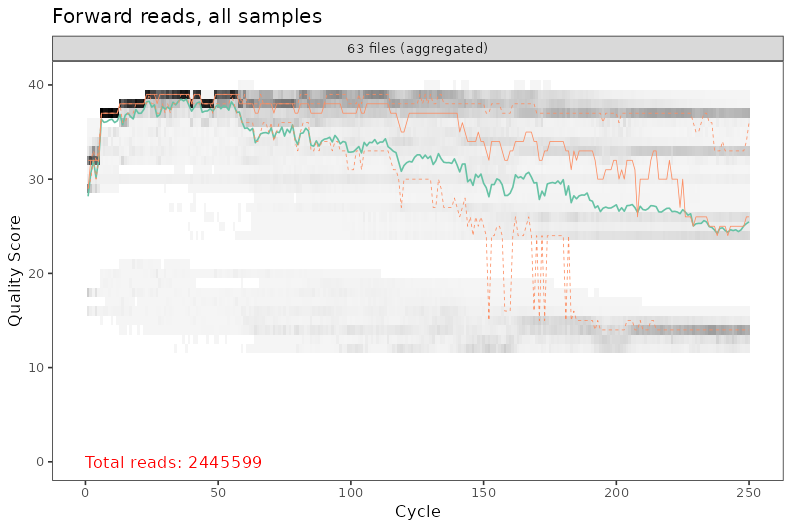

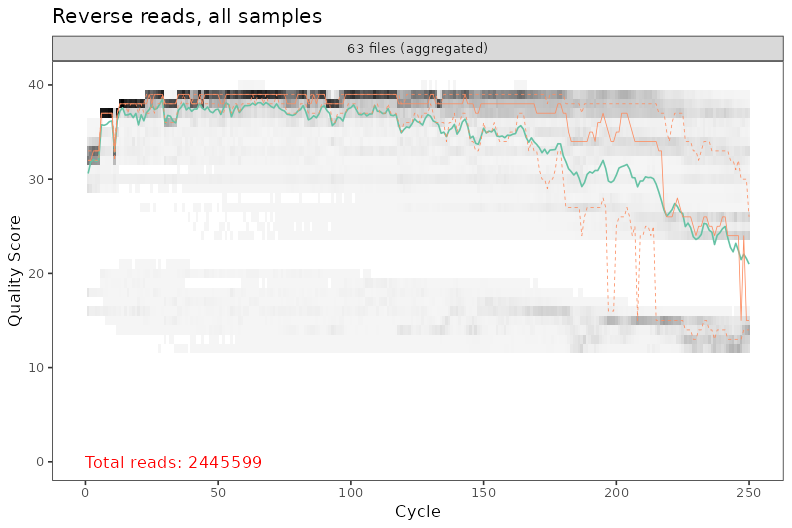

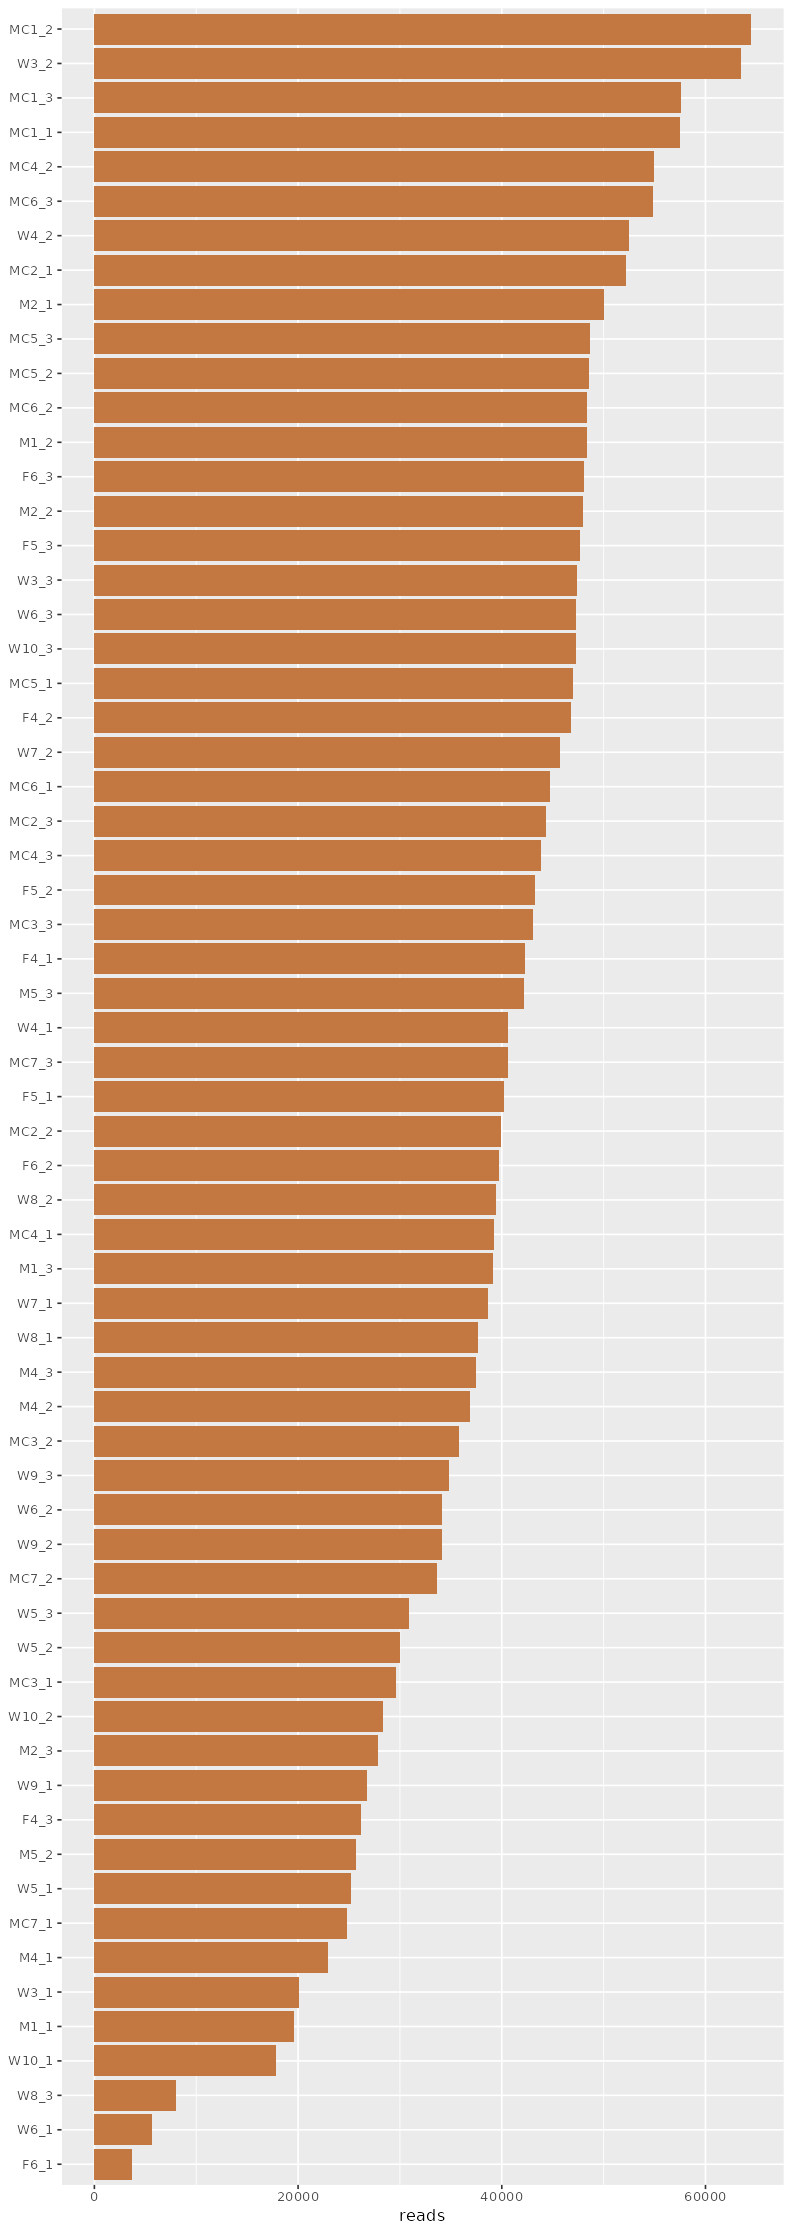

In [ ]:
step_start("n1", 1, 3, "Read Quality Report")
settings <- list(`r1_pattern` = "_R1", `r2_pattern` = "_R2", `n_reads` = 5000, `run_fastqc` = TRUE)   # this step's settings from the canvas (tested program, pinned by the platform)
# Read Quality Report: the reads as they arrive, per sample and per position.
if (!exists("mb_reads")) {
  files <- if (exists("READ_FILES") && length(READ_FILES)) READ_FILES else
    sort(list.files("data", pattern = "[.](fastq|fq)([.]gz)?$", full.names = TRUE))
  r1 <- if (length(settings$r1_pattern) && nzchar(settings$r1_pattern)) settings$r1_pattern else "_R1"
  r2 <- if (length(settings$r2_pattern) && nzchar(settings$r2_pattern)) settings$r2_pattern else "_R2"
  fwd <- files[grepl(r1, basename(files), fixed = TRUE)]
  rev <- files[grepl(r2, basename(files), fixed = TRUE)]
  if (!length(fwd)) { fwd <- files; rev <- character() }
  ids <- if (exists("df") && nrow(df)) as.character(df[[1]]) else character()
  sample_of <- function(b) {
    hit <- ids[startsWith(b, paste0(ids, "_")) | startsWith(b, paste0(ids, ".")) | startsWith(b, paste0(ids, "-"))]
    if (length(hit)) hit[which.max(nchar(hit))] else sub("[_.].*$", "", b)
  }
  mb_reads <- data.frame(sample = vapply(basename(fwd), sample_of, character(1), USE.NAMES = FALSE),
                         fwd = fwd, stringsAsFactors = FALSE)
  mb_reads$rev <- if (length(rev)) rev[match(sub(r1, r2, basename(fwd), fixed = TRUE), basename(rev))] else NA_character_
}
if (!nrow(mb_reads)) {
  step_skipped("n1", "no FASTQ files were found in the dataset")
} else {
  paired <- all(!is.na(mb_reads$rev))
  count_reads <- function(f) length(ShortRead::readFastq(f))
  mb_reads$reads <- vapply(mb_reads$fwd, count_reads, numeric(1))
  metric("n1", "samples", nrow(mb_reads))
  metric("n1", "paired_end", paired)
  metric("n1", "median_reads_per_sample", stats::median(mb_reads$reads))
  metric("n1", "min_reads_per_sample", min(mb_reads$reads))
  emit_preview("n1", data.frame(sample = mb_reads$sample, reads = mb_reads$reads,
    forward = basename(mb_reads$fwd), reverse = basename(mb_reads$rev)))
  # per-position quality from a sample of reads, the way DADA2 draws it
  n <- if (length(settings$n_reads)) settings$n_reads else 5000
  save_fig(dada2::plotQualityProfile(mb_reads$fwd, aggregate = TRUE, n = n) +
    ggplot2::ggtitle("Forward reads, all samples"), "n1__quality_forward")
  if (paired) save_fig(dada2::plotQualityProfile(mb_reads$rev, aggregate = TRUE, n = n) +
    ggplot2::ggtitle("Reverse reads, all samples"), "n1__quality_reverse")
  save_fig(ggplot2::ggplot(mb_reads, ggplot2::aes(stats::reorder(sample, reads), reads)) +
    ggplot2::geom_col(fill = "#C27840") + ggplot2::coord_flip() +
    ggplot2::labs(x = NULL, y = "reads"), "n1__reads_per_sample")
  # FastQC, the report every sequencing core sends: one HTML page per file
  if (!isFALSE(settings$run_fastqc)) {
    out <- tempfile("fastqc_"); dir.create(out)
    run_tool("fastqc", c("--outdir", out, "--quiet", "--threads", "2", mb_reads$fwd, stats::na.omit(mb_reads$rev)), node_id = "n1")
    status <- list()
    for (z in list.files(out, pattern = "_fastqc[.]zip$", full.names = TRUE)) {
      inner <- utils::unzip(z, list = TRUE)$Name
      s <- utils::read.delim(unz(z, grep("summary.txt$", inner, value = TRUE)[1]), header = FALSE, col.names = c("status", "module", "file"))
      status[[length(status) + 1]] <- s
    }
    for (h in list.files(out, pattern = "_fastqc[.]html$", full.names = TRUE)) {
      writeLines(readLines(h, warn = FALSE), file.path("artifacts", paste0("n1__", sub("[.]html$", "", basename(h)), ".html")))
    }
    if (length(status)) {
      st <- do.call(rbind, status)
      tab <- as.data.frame.matrix(table(st$module, st$status))
      tab <- data.frame(module = rownames(tab), tab, check.names = FALSE)
      metric("n1", "fastqc_modules_failed", sum(st$status == "FAIL"))
      metric("n1", "fastqc_modules_warned", sum(st$status == "WARN"))
      data.table::fwrite(tab, "artifacts/n1__fastqc_summary.csv")
    }
  }
}
step_done("n1", 1, 3, "Read Quality Report")

## Primer Trimming (Cutadapt)

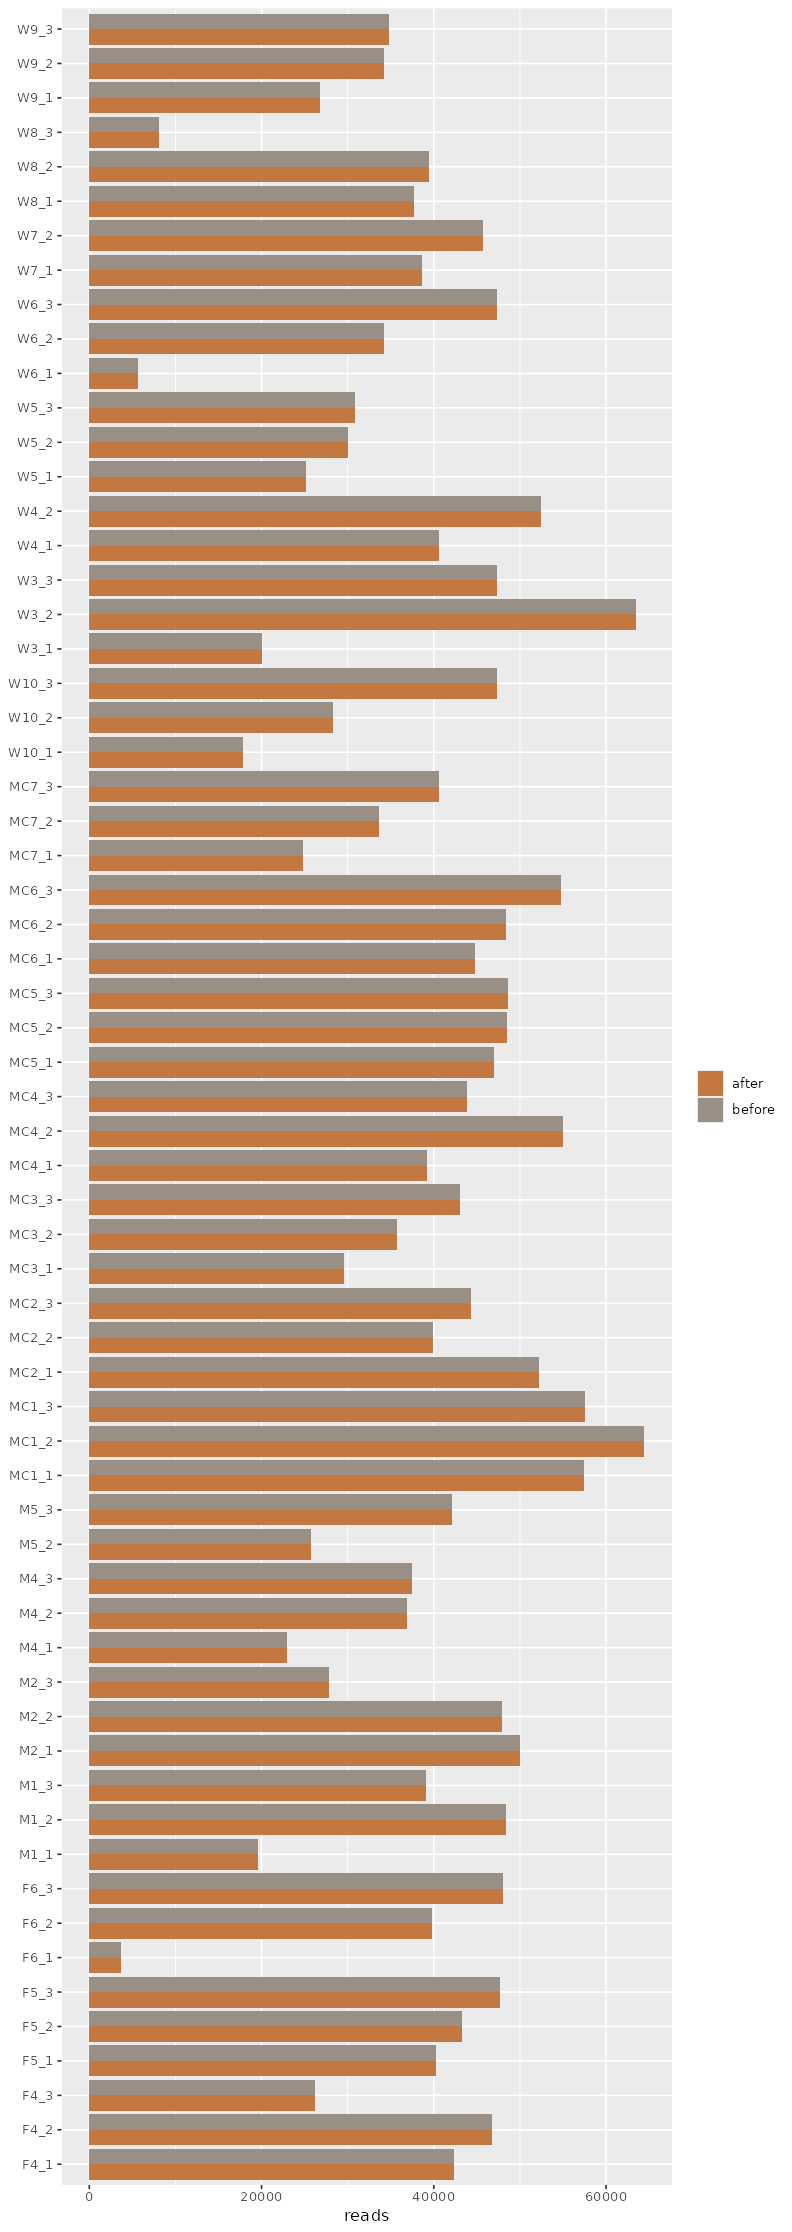

In [ ]:
step_start("n2", 2, 3, "Primer Trimming (Cutadapt)")
settings <- list(`primer_forward` = "CCAGCASCYGCGGTAATTCC", `primer_reverse` = "ACTTTCGTTCTTGAT", `error_rate` = 0.1, `min_length` = 50, `discard_untrimmed` = TRUE)   # this step's settings from the canvas (tested program, pinned by the platform)
# Primer Trimming (Cutadapt): remove the amplification primers from both ends,
# and their reverse complements where a short amplicon reads through.
if (!exists("mb_reads")) {
  files <- if (exists("READ_FILES") && length(READ_FILES)) READ_FILES else
    sort(list.files("data", pattern = "[.](fastq|fq)([.]gz)?$", full.names = TRUE))
  fwd <- files[grepl("_R1", basename(files), fixed = TRUE)]
  rev <- files[grepl("_R2", basename(files), fixed = TRUE)]
  if (!length(fwd)) { fwd <- files; rev <- character() }
  ids <- if (exists("df") && nrow(df)) as.character(df[[1]]) else character()
  sample_of <- function(b) {
    hit <- ids[startsWith(b, paste0(ids, "_")) | startsWith(b, paste0(ids, ".")) | startsWith(b, paste0(ids, "-"))]
    if (length(hit)) hit[which.max(nchar(hit))] else sub("[_.].*$", "", b)
  }
  mb_reads <- data.frame(sample = vapply(basename(fwd), sample_of, character(1), USE.NAMES = FALSE),
                         fwd = fwd, stringsAsFactors = FALSE)
  mb_reads$rev <- if (length(rev)) rev[match(sub("_R1", "_R2", basename(fwd), fixed = TRUE), basename(rev))] else NA_character_
}
fwd_primer <- toupper(gsub("\\s", "", settings$primer_forward))
rev_primer <- toupper(gsub("\\s", "", settings$primer_reverse))
if (!nzchar(fwd_primer)) {
  step_skipped("n2", "no forward primer was given")
} else {
  rc <- function(p) as.character(Biostrings::reverseComplement(Biostrings::DNAString(p)))
  paired <- all(!is.na(mb_reads$rev)) && nzchar(rev_primer)
  out <- tempfile("cutadapt_"); dir.create(out)
  rows <- list()
  trimmed <- mb_reads
  for (i in seq_len(nrow(mb_reads))) {
    f1 <- file.path(out, basename(mb_reads$fwd[i]))
    rep <- file.path(out, paste0(mb_reads$sample[i], ".json"))
    args <- c("-g", fwd_primer, "-e", as.character(settings$error_rate), "--minimum-length", as.character(settings$min_length),
              "-j", "2", "--json", rep, "-o", f1)
    if (paired) {
      f2 <- file.path(out, basename(mb_reads$rev[i]))
      args <- c(args, "-a", rc(rev_primer), "-G", rev_primer, "-A", rc(fwd_primer), "-p", f2)
    } else if (nzchar(rev_primer)) {
      args <- c(args, "-a", rc(rev_primer))
    }
    if (!isFALSE(settings$discard_untrimmed)) args <- c(args, "--discard-untrimmed")
    args <- c(args, "-n", "2", mb_reads$fwd[i], if (paired) mb_reads$rev[i])
    run_tool("cutadapt", args, node_id = if (i == 1) "n2" else NULL)
    j <- jsonlite::fromJSON(rep)
    rc_in <- j$read_counts$input
    rc_out <- j$read_counts$output
    with_primer <- j$read_counts$read1_with_adapter
    rows[[i]] <- data.frame(sample = mb_reads$sample[i], reads_in = rc_in, reads_out = rc_out,
                            with_primer = if (is.null(with_primer)) NA else with_primer)
    trimmed$fwd[i] <- f1
    if (paired) trimmed$rev[i] <- f2
  }
  tab <- do.call(rbind, rows)
  found <- sum(tab$with_primer, na.rm = TRUE) / max(sum(tab$reads_in), 1)
  # Reads that were trimmed before upload, or sequenced from past the primer,
  # carry no primer. Discarding every read without one would then discard the
  # dataset, so the step says so and the original reads go on, and what it
  # reports is what goes on, not what cutadapt would have kept. Such reads show
  # the primer by chance only (0.0% in the MiSeq SOP 16S reads, 0.2% in Bradley
  # et al.'s 18S reads). A library carrying two amplicons in the same reads
  # (Bakker 2018: ITS1 in 75%, ITS2 in 21%) shows a minor one far above that,
  # and its reads must be selected by the primer, never passed on whole.
  absent_below <- 0.05
  if (found < absent_below) {
    tab$reads_out <- tab$reads_in
    tab$note <- "no primer in the reads: passed on unchanged"
  }
  tab$kept_pct <- round(100 * tab$reads_out / pmax(tab$reads_in, 1), 1)
  metric("n2", "reads_in", sum(tab$reads_in))
  metric("n2", "reads_out", sum(tab$reads_out))
  metric("n2", "primer_found_pct", round(100 * found, 1))
  emit_preview("n2", tab)
  if (found < absent_below) {
    metric("n2", "primers_absent", TRUE)
    message("n2: the primer was found in ", round(100 * found, 1), "% of reads; the reads look already trimmed, so the original reads are used")
  } else {
    mb_raw_reads <- mb_reads
    mb_reads <- trimmed
    mb_reads <- mb_reads[file.exists(mb_reads$fwd) & tab$reads_out > 0, ]
  }
  long <- rbind(data.frame(sample = tab$sample, stage = "before", reads = tab$reads_in),
                data.frame(sample = tab$sample, stage = "after", reads = tab$reads_out))
  save_fig(ggplot2::ggplot(long, ggplot2::aes(sample, reads, fill = stage)) +
    ggplot2::geom_col(position = "dodge") + ggplot2::coord_flip() +
    ggplot2::scale_fill_manual(values = c(before = "#9A8F84", after = "#C27840")) +
    ggplot2::labs(x = NULL, y = "reads", fill = NULL), "n2__reads_before_after")
}
step_done("n2", 2, 3, "Primer Trimming (Cutadapt)")

## Filter & Trim Reads

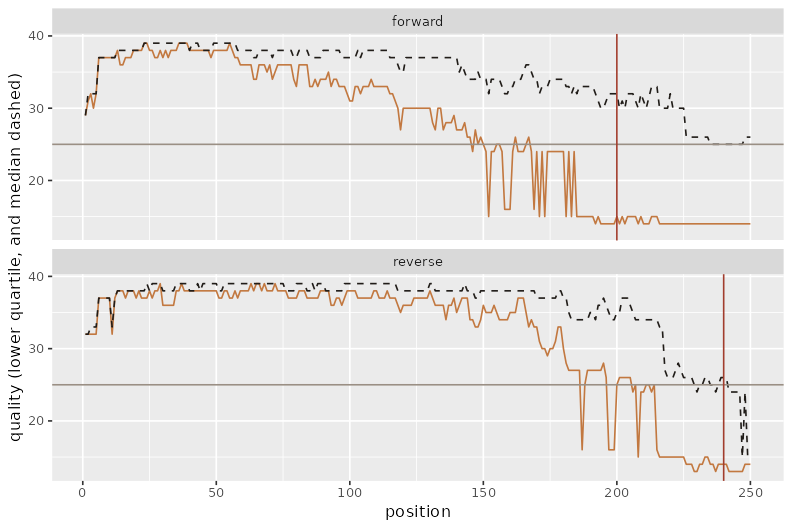

In [ ]:
step_start("n3", 3, 3, "Filter & Trim Reads")
settings <- list(`amplicon` = "18S V4", `amplicon_length` = 253, `auto_truncation` = TRUE, `quality_threshold` = 25, `min_overlap` = 20, `trunc_len_forward` = 240, `trunc_len_reverse` = 160, `max_ee_forward` = 2, `max_ee_reverse` = 2, `min_length` = 50)   # this step's settings from the canvas (tested program, pinned by the platform)
# Filter & Trim Reads: quality filtering, with the truncation lengths chosen
# from the reads' own quality profile unless they are set by hand.
if (!exists("mb_reads")) {
  files <- if (exists("READ_FILES") && length(READ_FILES)) READ_FILES else
    sort(list.files("data", pattern = "[.](fastq|fq)([.]gz)?$", full.names = TRUE))
  fwd <- files[grepl("_R1", basename(files), fixed = TRUE)]
  rev <- files[grepl("_R2", basename(files), fixed = TRUE)]
  if (!length(fwd)) { fwd <- files; rev <- character() }
  ids <- if (exists("df") && nrow(df)) as.character(df[[1]]) else character()
  sample_of <- function(b) {
    hit <- ids[startsWith(b, paste0(ids, "_")) | startsWith(b, paste0(ids, ".")) | startsWith(b, paste0(ids, "-"))]
    if (length(hit)) hit[which.max(nchar(hit))] else sub("[_.].*$", "", b)
  }
  mb_reads <- data.frame(sample = vapply(basename(fwd), sample_of, character(1), USE.NAMES = FALSE),
                         fwd = fwd, stringsAsFactors = FALSE)
  mb_reads$rev <- if (length(rev)) rev[match(sub("_R1", "_R2", basename(fwd), fixed = TRUE), basename(rev))] else NA_character_
}
paired <- all(!is.na(mb_reads$rev))
region <- settings$amplicon
amplicon_len <- switch(region, "16S V4" = 253, "16S V3-V4" = 465, "16S V4-V5" = 411, "18S V4" = 420, "18S V8-V9" = 350, "18S V9" = 130,
                       "ITS" = NA, as.numeric(settings$amplicon_length))
# The quality at each position, lower quartile, from a sample of reads
q_profile <- function(files, n = 20000) {
  each <- max(200, ceiling(n / length(files)))
  qs <- lapply(files, function(f) {
    s <- ShortRead::FastqSampler(f, each); fq <- ShortRead::yield(s); close(s)
    methods::as(Biostrings::quality(fq), "matrix")
  })
  width <- max(vapply(qs, ncol, numeric(1)))
  qs <- lapply(qs, function(m) { if (ncol(m) < width) cbind(m, matrix(NA, nrow(m), width - ncol(m))) else m })
  m <- do.call(rbind, qs)
  data.frame(position = seq_len(ncol(m)), q25 = apply(m, 2, stats::quantile, 0.25, na.rm = TRUE),
             median = apply(m, 2, stats::median, na.rm = TRUE))
}
choose_len <- function(p, threshold) {
  bad <- which(p$q25 < threshold)
  if (!length(bad)) nrow(p) else max(bad[1] - 1, 50)
}
pf <- q_profile(mb_reads$fwd)
pr <- if (paired) q_profile(mb_reads$rev) else NULL
threshold <- as.numeric(settings$quality_threshold)
if (identical(region, "ITS")) {
  # ITS lengths vary between taxa: truncating to one length would remove whole taxa
  tl <- c(0, 0); how <- "none (ITS lengths vary)"
} else if (isTRUE(settings$auto_truncation)) {
  tl <- c(choose_len(pf, threshold), if (paired) choose_len(pr, threshold) else 0)
  how <- sprintf("from the quality profile (lower quartile above Q%s)", threshold)
  # paired reads must still overlap across the amplicon to be merged
  need <- if (paired && !is.na(amplicon_len)) amplicon_len + as.numeric(settings$min_overlap) else 0
  if (paired && need > 0 && sum(tl) < need) {
    short <- need - sum(tl)
    grow_f <- min(nrow(pf) - tl[1], ceiling(short / 2)); tl[1] <- tl[1] + grow_f
    tl[2] <- min(nrow(pr), tl[2] + (need - sum(tl)))
    how <- paste0(how, ", lengthened to keep a ", settings$min_overlap, "-base overlap over the ", amplicon_len, "-base amplicon")
    if (sum(tl) < need) message("n3: the reads are too short to overlap across this amplicon; merging will lose most pairs")
  }
} else {
  tl <- c(as.numeric(settings$trunc_len_forward), if (paired) as.numeric(settings$trunc_len_reverse) else 0)
  how <- "set by hand"
}
metric("n3", "trunc_len_forward", tl[1])
if (paired) metric("n3", "trunc_len_reverse", tl[2])
metric("n3", "truncation", how)
filt_dir <- tempfile("filtered_"); dir.create(filt_dir)
filt_f <- file.path(filt_dir, paste0(mb_reads$sample, "_F_filt.fastq.gz"))
filt_r <- if (paired) file.path(filt_dir, paste0(mb_reads$sample, "_R_filt.fastq.gz")) else NULL
max_ee <- c(as.numeric(settings$max_ee_forward), as.numeric(settings$max_ee_reverse))
out <- if (paired) {
  dada2::filterAndTrim(mb_reads$fwd, filt_f, mb_reads$rev, filt_r, truncLen = tl, maxN = 0, maxEE = max_ee,
                       truncQ = 2, minLen = as.numeric(settings$min_length), rm.phix = TRUE, compress = TRUE, multithread = 2)
} else {
  dada2::filterAndTrim(mb_reads$fwd, filt_f, truncLen = tl[1], maxN = 0, maxEE = max_ee[1],
                       truncQ = 2, minLen = as.numeric(settings$min_length), rm.phix = TRUE, compress = TRUE, multithread = 2)
}
mb_filter_counts <- data.frame(sample = mb_reads$sample, input = out[, 1], filtered = out[, 2])
keep <- file.exists(filt_f) & out[, 2] > 0
mb_filt <- data.frame(sample = mb_reads$sample[keep], fwd = filt_f[keep],
                      rev = if (paired) filt_r[keep] else NA_character_, stringsAsFactors = FALSE)
metric("n3", "reads_in", sum(out[, 1]))
metric("n3", "reads_kept", sum(out[, 2]))
metric("n3", "reads_kept_pct", round(100 * sum(out[, 2]) / max(sum(out[, 1]), 1), 1))
if (any(!keep)) metric("n3", "samples_emptied", paste(mb_reads$sample[!keep], collapse = ", "))
emit_preview("n3", transform(mb_filter_counts, kept_pct = round(100 * filtered / pmax(input, 1), 1)))
prof <- rbind(transform(pf, read = "forward"), if (paired) transform(pr, read = "reverse"))
cut <- data.frame(read = c("forward", if (paired) "reverse"), at = tl[seq_len(if (paired) 2 else 1)])
save_fig(ggplot2::ggplot(prof, ggplot2::aes(position, q25)) + ggplot2::geom_line(colour = "#C27840") +
  ggplot2::geom_line(ggplot2::aes(y = median), colour = "#201C18", linetype = "dashed") +
  ggplot2::geom_hline(yintercept = threshold, colour = "#9A8F84") +
  { if (all(cut$at > 0)) ggplot2::geom_vline(data = cut, ggplot2::aes(xintercept = at), colour = "#A13D2D") } +
  ggplot2::facet_wrap(~read, ncol = 1) + ggplot2::labs(y = "quality (lower quartile, and median dashed)"),
  "n3__truncation_choice")
step_done("n3", 3, 3, "Filter & Trim Reads")

## ASV Inference (DADA2)

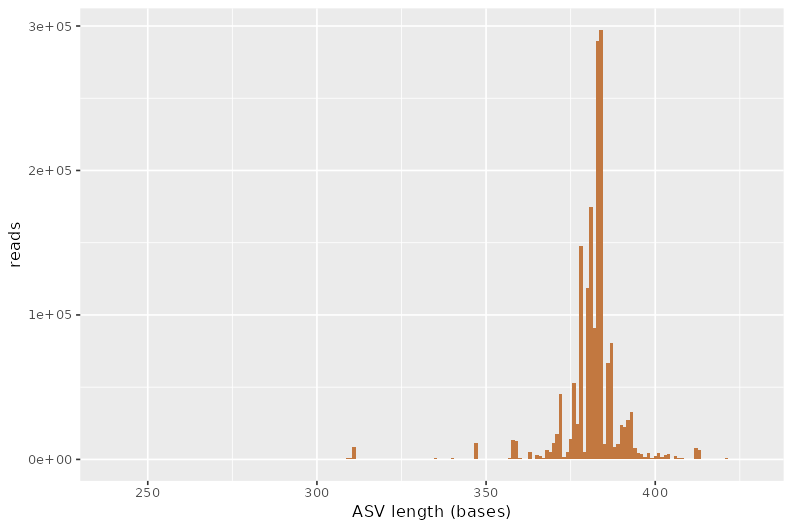

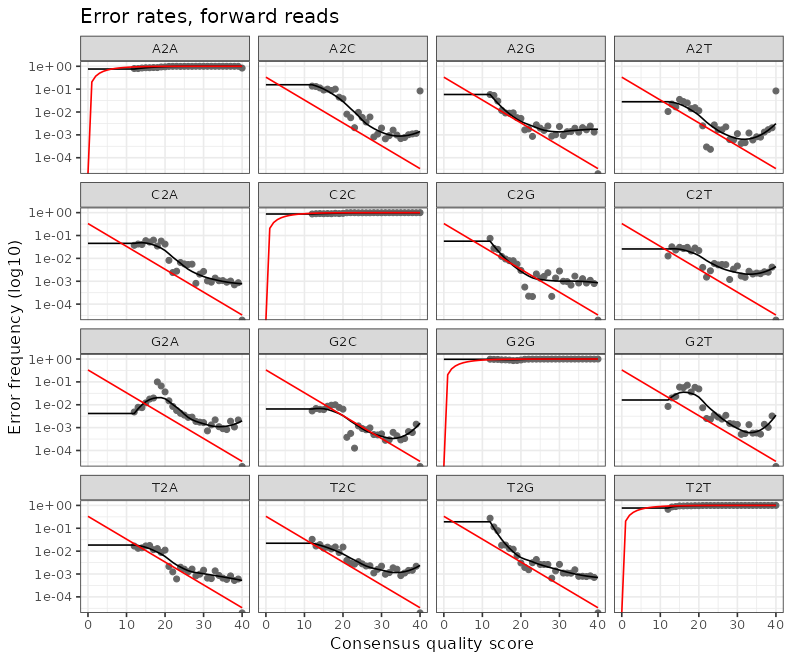

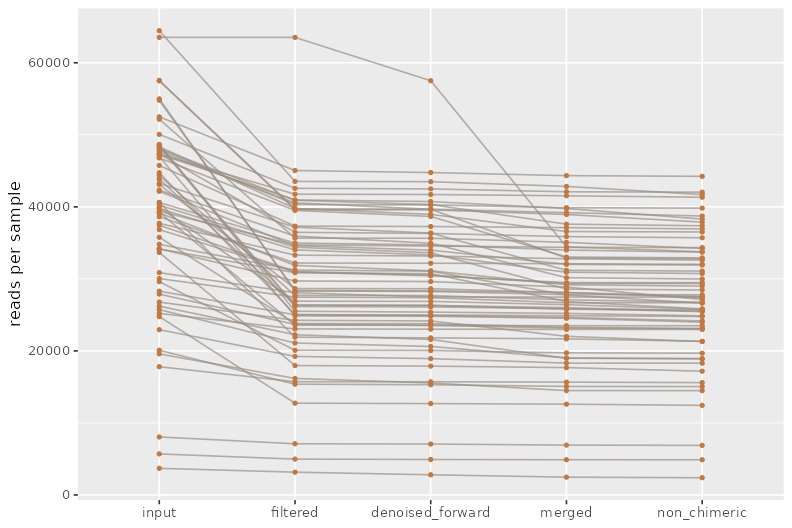

In [ ]:
step_start("n4", 4, 5, "ASV Inference (DADA2)")
settings <- list(`sample_col` = "sample", `pool` = "false", `min_overlap` = 12, `chimera_method` = "consensus", `learn_bases` = 100000000, `seed` = 100)   # this step's settings from the canvas (tested program, pinned by the platform)
# ASV Inference (DADA2): learn the run's error rates, denoise each sample into
# exact sequence variants, merge the pairs, and remove chimeras.
if (!exists("mb_filt")) {
  step_skipped("n4", "run Filter & Trim Reads first: DADA2 needs filtered reads")
} else {
  set.seed(as.integer(settings$seed))
  paired <- all(!is.na(mb_filt$rev))
  pool <- switch(settings$pool, "pseudo" = "pseudo", "true" = TRUE, FALSE)
  nbases <- as.numeric(settings$learn_bases)
  err_f <- dada2::learnErrors(mb_filt$fwd, nbases = nbases, multithread = 2, verbose = FALSE)
  dd_f <- dada2::dada(mb_filt$fwd, err = err_f, pool = pool, multithread = 2, verbose = FALSE)
  if (inherits(dd_f, "dada")) dd_f <- list(dd_f)
  names(dd_f) <- mb_filt$sample
  if (paired) {
    err_r <- dada2::learnErrors(mb_filt$rev, nbases = nbases, multithread = 2, verbose = FALSE)
    dd_r <- dada2::dada(mb_filt$rev, err = err_r, pool = pool, multithread = 2, verbose = FALSE)
    if (inherits(dd_r, "dada")) dd_r <- list(dd_r)
    names(dd_r) <- mb_filt$sample
    merged <- dada2::mergePairs(dd_f, mb_filt$fwd, dd_r, mb_filt$rev, minOverlap = as.integer(settings$min_overlap), verbose = FALSE)
    if (is.data.frame(merged)) merged <- list(merged)
    names(merged) <- mb_filt$sample
    seqtab_all <- dada2::makeSequenceTable(merged)
  } else {
    seqtab_all <- dada2::makeSequenceTable(dd_f)
  }
  seqtab <- dada2::removeBimeraDenovo(seqtab_all, method = settings$chimera_method, multithread = 2, verbose = FALSE)
  rownames(seqtab) <- mb_filt$sample
  getN <- function(x) sum(dada2::getUniques(x))
  mb_track <- data.frame(sample = mb_filt$sample,
    denoised_forward = vapply(dd_f, getN, numeric(1)),
    merged = if (paired) vapply(merged, getN, numeric(1)) else vapply(dd_f, getN, numeric(1)),
    non_chimeric = rowSums(seqtab))
  if (exists("mb_filter_counts")) mb_track <- merge(mb_filter_counts, mb_track, by = "sample", all.y = TRUE)
  # ASVs are named by abundance; the sequence stays with each name
  ord <- order(-colSums(seqtab))
  seqtab <- seqtab[, ord, drop = FALSE]
  asv_seqs <- Biostrings::DNAStringSet(colnames(seqtab))
  names(asv_seqs) <- paste0("ASV", seq_along(asv_seqs))
  colnames(seqtab) <- names(asv_seqs)
  meta <- if (exists("df") && nrow(df)) df else data.frame(sample = rownames(seqtab))
  scol <- settings$sample_col
  if (!length(scol) || !nzchar(scol) || !(scol %in% names(meta))) {
    scol <- names(meta)[which.max(vapply(meta, function(v) sum(as.character(v) %in% rownames(seqtab)), numeric(1)))]
  }
  meta <- meta[!duplicated(meta[[scol]]), , drop = FALSE]
  rownames(meta) <- as.character(meta[[scol]])
  meta <- meta[rownames(seqtab), , drop = FALSE]
  rownames(meta) <- rownames(seqtab)
  meta[[scol]] <- rownames(seqtab)
  ps <- phyloseq::phyloseq(phyloseq::otu_table(seqtab, taxa_are_rows = FALSE),
                           phyloseq::sample_data(meta), phyloseq::refseq(asv_seqs))
  mb_sample_col <- scol
  metric("n4", "asvs", ncol(seqtab))
  metric("n4", "samples", nrow(seqtab))
  metric("n4", "reads_non_chimeric", sum(seqtab))
  metric("n4", "chimeric_reads_pct", round(100 * (1 - sum(seqtab) / max(sum(seqtab_all), 1)), 2))
  if ("input" %in% names(mb_track)) metric("n4", "reads_retained_pct", round(100 * sum(mb_track$non_chimeric) / max(sum(mb_track$input), 1), 1))
  emit_preview("n4", mb_track)
  # the whole table, every sample: the preview shows only its first rows, and a
  # chimera or merging rate per sample is what a methods comparison reads
  data.table::fwrite(mb_track, "artifacts/n4__reads_through_the_steps.csv")
  save_fig(dada2::plotErrors(err_f, nominalQ = TRUE) + ggplot2::ggtitle("Error rates, forward reads"), "n4__error_rates", height = 6)
  lens <- data.frame(length = Biostrings::width(asv_seqs), reads = colSums(seqtab))
  save_fig(ggplot2::ggplot(lens, ggplot2::aes(length, weight = reads)) + ggplot2::geom_histogram(binwidth = 1, fill = "#C27840") +
    ggplot2::labs(x = "ASV length (bases)", y = "reads"), "n4__asv_lengths")
  long <- stats::reshape(mb_track, direction = "long", varying = setdiff(names(mb_track), "sample"),
                         v.names = "reads", timevar = "stage", times = setdiff(names(mb_track), "sample"), idvar = "sample")
  long$stage <- factor(long$stage, levels = setdiff(names(mb_track), "sample"))
  save_fig(ggplot2::ggplot(long, ggplot2::aes(stage, reads, group = sample)) + ggplot2::geom_line(colour = "#9A8F84", alpha = 0.7) +
    ggplot2::geom_point(colour = "#C27840", size = 1) + ggplot2::labs(x = NULL, y = "reads per sample"), "n4__reads_through_the_steps")
  # The denoising objects hold every read's assignment and are not needed
  # after this step; kept, they cost PICRUSt2 the memory it needs later.
  rm(list = intersect(c("dd_f", "dd_r", "merged", "seqtab_all"), ls())); invisible(gc())
}
step_done("n4", 4, 5, "ASV Inference (DADA2)")

## Mock Community Check

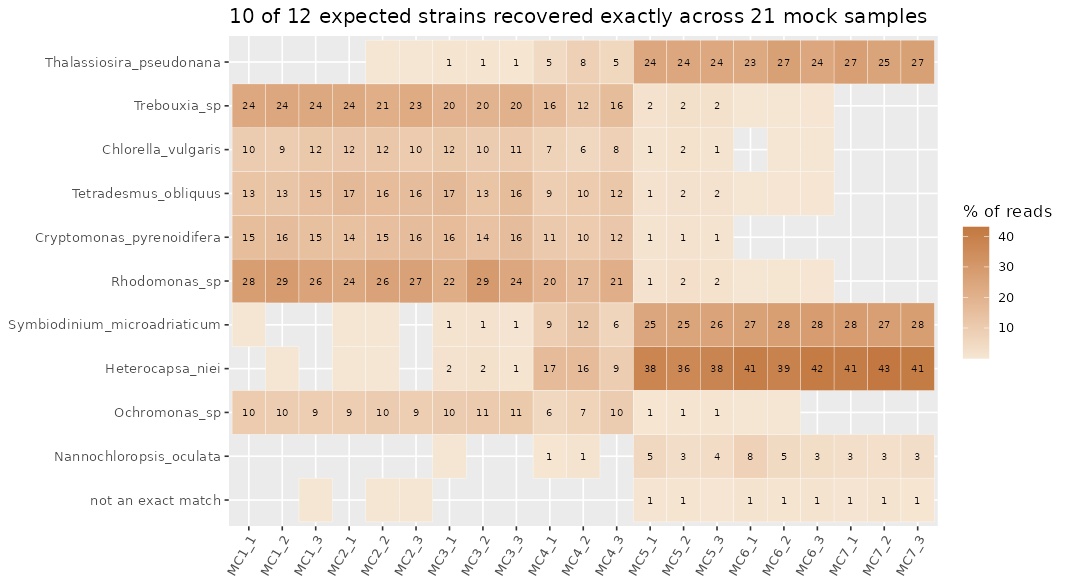

In [ ]:
step_start("n15", 5, 5, "Mock Community Check")
settings <- list(`mock_sample` = "MC", `reference_file` = "mock_18S_reference.fasta", `expected_file` = "mock_expected_members.csv", `min_reads` = 1, `min_cover_pct` = 90)   # this step's settings from the canvas (tested program, pinned by the platform)
# Mock Community Check: a sample of known composition, sequenced with the study,
# is the one place where the right answer is known. The ASVs found in it are
# compared with the expected sequences: how many expected strains were
# recovered exactly, how many ASVs match nothing expected, and how much of the
# sample those unexpected ASVs hold (contamination, chimeras, errors left in).
# A study may carry several mocks (communities of different make-up, each in
# replicate, as in Bradley et al. 2016). Each is checked on its own; a table of
# which strains each should hold, and optionally in what proportion, names a
# strain missing where it was put, or present where it was not.
if (!exists("ps") || is.null(ps) || is.null(phyloseq::refseq(ps, errorIfNULL = FALSE))) {
  step_skipped("n15", "the check needs the ASV sequences: run ASV Inference (DADA2), or import a table with its sequences")
} else {
  samples <- phyloseq::sample_names(ps)
  # one sample, several separated by commas, or the start several share ("MC"
  # for MC1_1, MC1_2 and so on); left empty, every sample with "mock" in its name
  want <- trimws(unlist(strsplit(paste(settings$mock_sample, collapse = ","), ",", fixed = TRUE)))
  want <- want[nzchar(want)]
  mocks <- if (!length(want)) samples[grepl("mock", samples, ignore.case = TRUE)] else
    unique(unlist(lapply(want, function(w) if (w %in% samples) w else samples[startsWith(samples, w)])))
  fastas <- list.files("data", pattern = "[.](fasta|fa|fna)(.gz)?$", full.names = TRUE, ignore.case = TRUE)
  refname <- settings$reference_file
  ref_path <- if (length(refname) && nzchar(refname)) file.path("data", basename(refname)) else
    fastas[grepl("mock", basename(fastas), ignore.case = TRUE)][1]
  if (!length(mocks)) {
    step_skipped("n15", sprintf("no mock sample: name it in the settings (samples: %s)", paste(utils::head(samples, 8), collapse = ", ")))
  } else if (!length(ref_path) || is.na(ref_path) || !file.exists(ref_path)) {
    step_skipped("n15", "no reference of the expected sequences: add a FASTA of the mock's strains to the dataset and name it in the settings")
  } else {
    ref <- Biostrings::readDNAStringSet(ref_path)
    counts <- as(phyloseq::otu_table(ps), "matrix"); if (!phyloseq::taxa_are_rows(ps)) counts <- t(counts)
    min_reads <- max(1, as.numeric(settings$min_reads))
    # A strain can carry several copies ("S.aureus.1", "S.aureus.2"): strains
    # are counted by name, sequences by entry. Strains whose region is identical
    # share one ASV, so an ASV names every strain it matches exactly.
    strain_of <- function(x) sub("[._-][0-9]+$", "", sub("\\s.*", "", x))
    strains <- unique(strain_of(names(ref)))
    both <- c(ref, Biostrings::reverseComplement(ref))
    refs_chr <- as.character(both)
    cover <- suppressWarnings(as.numeric(settings$min_cover_pct))
    cover <- if (!length(cover) || is.na(cover[1])) 0.9 else min(100, max(50, cover[1])) / 100
    # Each ASV seen in any mock, against the expected sequences: the fewest
    # mismatches inside any of them (an ASV is a stretch of the full-length
    # gene), or, where a reference ends inside the amplicon (a partial GenBank
    # sequence), an exact match over the part of the ASV it covers.
    in_any <- rownames(counts)[rowSums(counts[, mocks, drop = FALSE] >= min_reads) > 0]
    asv_seqs <- as.character(phyloseq::refseq(ps)[in_any])
    judge <- function(s) {
      for (k in 0:3) {
        i <- which(Biostrings::vcountPattern(s, both, max.mismatch = k) > 0)
        if (length(i)) return(list(k = k, strains = unique(strain_of(names(both)[i])), covered = nchar(s)))
      }
      # a reference that ends (or starts) inside the ASV, or lies wholly inside
      # it (a Sanger sequence that stops short of both primers): exact over the
      # part it covers, if that is at least the share the settings ask for
      n <- nchar(s); need <- ceiling(cover * n); best <- NULL
      if (need <= n - 1L) for (m in seq.int(n - 1L, need)) {
        i <- which(endsWith(refs_chr, substr(s, 1L, m)) | startsWith(refs_chr, substr(s, n - m + 1L, n)))
        if (length(i)) { best <- list(k = 0, strains = unique(strain_of(names(both)[i])), covered = m); break }
      }
      short <- which(nchar(refs_chr) >= need & nchar(refs_chr) < n)
      inside <- short[vapply(refs_chr[short], function(r) grepl(r, s, fixed = TRUE), logical(1))]
      if (length(inside) && (is.null(best) || max(nchar(refs_chr[inside])) > best$covered)) {
        top <- inside[nchar(refs_chr[inside]) == max(nchar(refs_chr[inside]))]
        best <- list(k = 0, strains = unique(strain_of(names(both)[top])), covered = max(nchar(refs_chr[inside])))
      }
      if (!is.null(best)) return(best)
      list(k = NA_real_, strains = character(0), covered = 0)
    }
    judged <- stats::setNames(lapply(asv_seqs, judge), in_any)
    verdict_of <- function(j, n) {
      if (is.na(j$k)) "not expected" else if (j$k == 0 && j$covered < n) "exact over a partial reference"
      else if (j$k == 0) "exact match" else sprintf("%d mismatch%s", j$k, ifelse(j$k == 1, "", "es"))
    }
    # Which strains each mock should hold, and in what share: a table in the
    # dataset with a sample (or community) column, a strain column and an
    # optional proportion. A community name covers its replicates (MC1 for
    # MC1_1, MC1_2, MC1_3).
    expected_for <- function(mk) NULL
    exp_name <- settings$expected_file
    if (length(exp_name) && nzchar(exp_name)) {
      exp_path <- file.path("data", basename(exp_name))
      if (!file.exists(exp_path)) {
        message("n15: the expected composition table ", basename(exp_name), " is not in the dataset; every strain is expected in every mock")
      } else {
        et <- data.table::fread(exp_path, data.table = FALSE)
        nm <- tolower(names(et))
        pick <- function(opts) { i <- which(nm %in% opts); if (length(i)) names(et)[i[1]] else NA_character_ }
        s_col <- pick(c("sample", "mock", "community")); t_col <- pick(c("strain", "taxon", "species", "member"))
        p_col <- pick(c("proportion", "share", "fraction", "abundance", "expected"))
        if (is.na(s_col) || is.na(t_col)) {
          message("n15: the expected composition table needs a sample (or community) column and a strain column; it was not used")
        } else {
          et[[t_col]] <- as.character(et[[t_col]])
          unknown <- setdiff(unique(et[[t_col]]), strains)
          if (length(unknown)) message("n15: strains in the expected table with no reference sequence: ", paste(unknown, collapse = ", "))
          expected_for <- function(mk) {
            key <- as.character(et[[s_col]])
            rows <- et[key == mk | startsWith(mk, paste0(key, "_")) | startsWith(mk, paste0(key, ".")) | startsWith(mk, paste0(key, "-")), , drop = FALSE]
            if (!nrow(rows)) return(NULL)
            p <- if (!is.na(p_col)) as.numeric(rows[[p_col]]) else rep(NA_real_, nrow(rows))
            if (all(!is.na(p)) && sum(p) > 0) p <- p / sum(p)
            stats::setNames(p, rows[[t_col]])
          }
        }
      }
    }
    asv_rows <- list(); sample_rows <- list(); share_rows <- list()
    for (mk in mocks) {
      x <- counts[, mk]; x <- sort(x[x >= min_reads], decreasing = TRUE)
      exp_here <- expected_for(mk)
      exp_strains <- if (is.null(exp_here)) strains else names(exp_here)
      if (!length(x)) {
        sample_rows[[mk]] <- data.frame(sample = mk, reads = 0, asvs = 0, asvs_exact = 0, asvs_not_expected = 0,
                                        reads_not_exact_pct = NA, strains_expected = length(exp_strains), strains_found = 0,
                                        strains_missing = paste(exp_strains, collapse = ", "), strains_unexpected = "")
        next
      }
      j <- judged[names(x)]
      verdict <- mapply(verdict_of, j, nchar(asv_seqs[names(x)]))
      named <- vapply(j, function(v) if (length(v$strains)) paste(v$strains, collapse = "; ") else NA_character_, character(1))
      res <- data.frame(sample = mk, asv = names(x), reads = as.numeric(x), share = round(100 * as.numeric(x) / sum(x), 2),
                        mismatches = vapply(j, `[[`, numeric(1), "k"), expected_strain = unname(named),
                        verdict = unname(verdict), stringsAsFactors = FALSE)
      exact <- res$verdict %in% c("exact match", "exact over a partial reference")
      found <- unique(unlist(strsplit(stats::na.omit(res$expected_strain[exact]), "; ")))
      # each strain's share of the sample, from its exact ASVs (an ASV shared
      # by strains that cannot be told apart is credited to the pair)
      if (any(exact)) {
        sh <- tapply(res$reads[exact], res$expected_strain[exact], sum)
        share_rows[[mk]] <- data.frame(sample = mk, strain = names(sh), share = 100 * as.numeric(sh) / sum(x))
      }
      if (any(!exact)) share_rows[[paste0(mk, "~")]] <- data.frame(sample = mk, strain = "not an exact match",
                                                                     share = 100 * sum(res$reads[!exact]) / sum(x))
      sample_rows[[mk]] <- data.frame(
        sample = mk, reads = sum(x), asvs = nrow(res), asvs_exact = sum(exact),
        asvs_not_expected = sum(res$verdict == "not expected"),
        reads_not_exact_pct = round(100 * sum(res$reads[!exact]) / sum(x), 2),
        strains_expected = length(exp_strains), strains_found = length(intersect(found, exp_strains)),
        strains_missing = paste(setdiff(exp_strains, found), collapse = ", "),
        strains_unexpected = if (is.null(exp_here)) "" else paste(setdiff(found, exp_strains), collapse = ", "))
      asv_rows[[mk]] <- res
    }
    res <- do.call(rbind, asv_rows); summ <- do.call(rbind, sample_rows)
    exact_all <- !is.null(res) && nrow(res) > 0
    ok <- if (exact_all) res$verdict %in% c("exact match", "exact over a partial reference") else logical(0)
    found_all <- if (exact_all) unique(unlist(strsplit(stats::na.omit(res$expected_strain[ok]), "; "))) else character(0)
    expected_any <- unique(unlist(lapply(mocks, function(mk) { e <- expected_for(mk); if (is.null(e)) strains else names(e) })))
    asv_set <- if (exact_all) unique(res$asv) else character(0)
    asv_ok <- if (exact_all) unique(res$asv[ok]) else character(0)
    metric("n15", "mock_sample", if (length(mocks) == 1) mocks else sprintf("%d samples (%s)", length(mocks), paste(utils::head(mocks, 4), collapse = ", ")))
    metric("n15", "mock_samples", length(mocks))
    metric("n15", "expected_strains", length(strains))
    metric("n15", "expected_sequences", length(ref))
    metric("n15", "asvs_shared_by_strains", if (exact_all) length(unique(res$asv[grepl(";", res$expected_strain)])) else 0)
    metric("n15", "strains_missing", if (length(setdiff(expected_any, found_all))) paste(setdiff(expected_any, found_all), collapse = ", ") else "none")
    metric("n15", "asvs_in_mock", length(asv_set))
    metric("n15", "asvs_exact_match", length(asv_ok))
    metric("n15", "asvs_exact_over_partial_reference", if (exact_all) length(unique(res$asv[res$verdict == "exact over a partial reference"])) else 0)
    metric("n15", "strains_recovered", length(intersect(found_all, strains)))
    metric("n15", "asvs_not_expected", if (exact_all) length(unique(res$asv[res$verdict == "not expected"])) else 0)
    metric("n15", "reads_not_exact_pct", if (exact_all) round(100 * sum(res$reads[!ok]) / max(sum(res$reads), 1), 2) else NA)
    if (length(mocks) > 1) {
      metric("n15", "samples_with_a_strain_missing", sum(nzchar(summ$strains_missing)))
      if (!is.null(expected_for(mocks[1])) || any(nzchar(summ$strains_unexpected)))
        metric("n15", "samples_with_an_unexpected_strain", sum(nzchar(summ$strains_unexpected)))
    }
    if (exact_all) {
      data.table::fwrite(res, "artifacts/n15__mock_community.csv")
      emit_preview("n15", if (length(mocks) == 1) res[, setdiff(names(res), "sample")] else summ)
    }
    data.table::fwrite(summ, "artifacts/n15__mock_samples.csv")
    if (length(mocks) == 1 && exact_all) {
      mock <- mocks
      res$asv <- factor(res$asv, levels = rev(res$asv))
      save_fig(ggplot2::ggplot(res, ggplot2::aes(asv, reads, fill = verdict)) + ggplot2::geom_col() + ggplot2::coord_flip() +
        ggplot2::scale_fill_manual(values = c("exact match" = "#C27840", "exact over a partial reference" = "#C27840",
                                              "1 mismatch" = "#D9A577", "2 mismatches" = "#D9A577",
                                              "3 mismatches" = "#D9A577", "not expected" = "#3D5A80")) +
        ggplot2::labs(x = NULL, y = sprintf("reads in %s", mock), fill = NULL,
                      title = sprintf("%d of %d expected strains recovered exactly; %d ASV(s) not expected",
                                      length(intersect(found_all, strains)), length(strains), sum(res$verdict == "not expected"))),
        "n15__mock_community", width = 7.2, height = max(4, 0.25 * nrow(res) + 1.5))
    } else if (length(share_rows)) {
      # every mock at once: each strain's share of each sample, in the order the
      # reference lists the strains, with what matched nothing exactly below
      sh <- do.call(rbind, share_rows)
      ord <- c(intersect(strains, unique(sh$strain)), setdiff(unique(sh$strain), c(strains, "not an exact match")),
               intersect("not an exact match", unique(sh$strain)))
      sh$strain <- factor(sh$strain, levels = rev(ord))
      sh$sample <- factor(sh$sample, levels = mocks)
      save_fig(ggplot2::ggplot(sh, ggplot2::aes(sample, strain, fill = share)) + ggplot2::geom_tile(colour = "white") +
        ggplot2::geom_text(ggplot2::aes(label = ifelse(share >= 0.5, sprintf("%.0f", share), "")), size = 2.4) +
        ggplot2::scale_fill_gradient(low = "#F5E6D3", high = "#C27840", name = "% of reads") +
        ggplot2::labs(x = NULL, y = NULL, title = sprintf("%d of %d expected strains recovered exactly across %d mock samples",
                                                          length(intersect(found_all, strains)), length(strains), length(mocks))) +
        ggplot2::theme(axis.text.x = ggplot2::element_text(angle = 60, hjust = 1)),
        "n15__mock_community", width = max(6, 0.32 * length(mocks) + 3), height = max(4, 0.3 * length(ord) + 1.8))
      # expected against observed, where the table gives proportions
      fold <- do.call(rbind, lapply(mocks, function(mk) {
        e <- expected_for(mk); if (is.null(e) || all(is.na(e))) return(NULL)
        o <- sh[sh$sample == mk, ]
        data.frame(sample = mk, strain = names(e), expected = 100 * as.numeric(e),
                   observed = vapply(names(e), function(s) sum(o$share[as.character(o$strain) == s]), numeric(1)))
      }))
      if (!is.null(fold) && nrow(fold)) {
        fold$fold <- ifelse(fold$expected > 0, fold$observed / fold$expected, NA)
        data.table::fwrite(fold, "artifacts/n15__mock_expected_vs_observed.csv")
        per <- stats::aggregate(fold ~ strain, data = fold[fold$expected > 0, ], FUN = mean)
        metric("n15", "mean_fold_observed_over_expected", round(mean(per$fold), 3))
        save_fig(ggplot2::ggplot(fold[fold$expected > 0, ], ggplot2::aes(expected, observed, colour = strain)) +
          ggplot2::geom_abline(slope = 1, intercept = 0, linetype = 2, colour = "grey50") + ggplot2::geom_point(size = 2) +
          ggplot2::labs(x = "expected % of reads", y = "observed % of reads", colour = NULL,
                        title = "Each strain's share, expected against observed"),
          "n15__mock_expected_vs_observed", width = 7.2, height = 5)
      }
    }
  }
}
step_done("n15", 5, 5, "Mock Community Check")

## Taxonomy Assignment

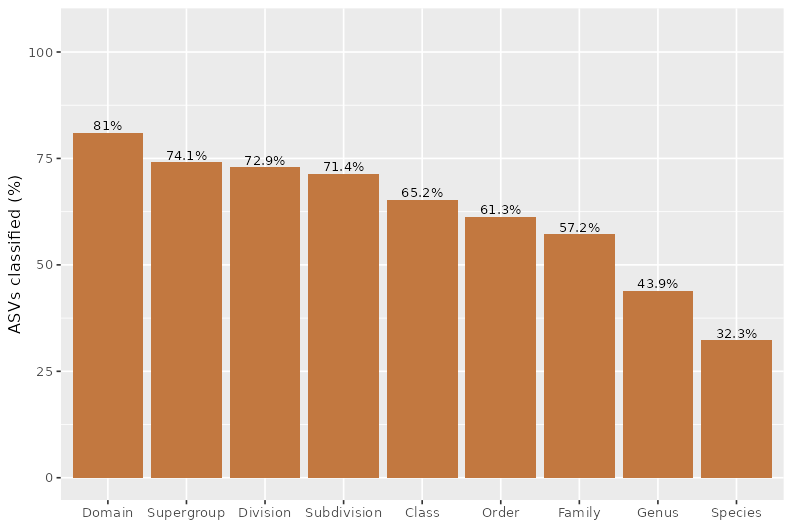

In [ ]:
step_start("n5", 5, 6, "Taxonomy Assignment")
settings <- list(`reference` = "PR2 5.0.0 (18S)", `min_bootstrap` = 50, `species` = TRUE)   # this step's settings from the canvas (tested program, pinned by the platform)
# Taxonomy Assignment: the naive Bayesian classifier (the RDP method, as DADA2
# implements it) against a curated reference, with exact species matches for
# 16S and ITS; for PR2 (18S), the IDTAXA classifier PR2 trained.
if (!exists("ps") || is.null(ps)) {
  step_skipped("n5", "run ASV Inference (DADA2) or Import Feature Table first")
} else if (is.null(phyloseq::refseq(ps, errorIfNULL = FALSE))) {
  step_skipped("n5", "the feature table carries no ASV sequences to classify")
} else {
  refdir <- "/opt/alkhemyst/refs/microbiome"
  # The naive Bayesian classifier holds a k-mer profile for every label at its
  # lowest rank, 256 KB each (65,536 eight-mers as floats). SILVA's genera fit
  # in about 4 GB. PR2 has 53,594 species and 26,232 genera (14 GB and 7 GB) and
  # UNITE 32,940 species (8.4 GB), past the runner (Bradley et al. 2016 and
  # Bakker 2018 both stopped here, 2 October 2026). PR2 publishes a trained
  # IDTAXA classifier (DECIPHER), which classifies to species in 2.5 GB. UNITE's
  # 6,062 genera need 1.5 GB: the classifier goes to genus and species are added
  # by exact match, as they are for 16S.
  ref <- switch(settings$reference,
    "PR2 5.0.0 (18S)" = list(method = "idtaxa", file = "pr2_version_5.0.0_SSU.decipher.trained.rds",
      levels = c("Domain", "Supergroup", "Division", "Subdivision", "Class", "Order", "Family", "Genus", "Species")),
    "UNITE 10.0 (ITS, fungi)" = list(method = "dada2", file = "unite_fungi_v10.0.fasta", species = "exact", rc = TRUE,
      to_genus = TRUE, levels = c("Kingdom", "Phylum", "Class", "Order", "Family", "Genus")),
    list(method = "dada2", file = "silva_nr99_v138.1_train_set.fa.gz", species = "silva_species_assignment_v138.1.fa.gz", rc = FALSE,
      levels = c("Kingdom", "Phylum", "Class", "Order", "Family", "Genus")))
  seqs <- as.character(phyloseq::refseq(ps))
  set.seed(100)
  if (identical(ref$method, "idtaxa")) {
    trained <- readRDS(file.path(refdir, ref$file))
    ids <- DECIPHER::IdTaxa(Biostrings::DNAStringSet(seqs), trained, strand = "top",
                            threshold = as.numeric(settings$min_bootstrap), processors = 2, verbose = FALSE)
    rm(trained); invisible(gc(verbose = FALSE))
    # the ranks below the confidence threshold come back as "unclassified_<parent>"
    taxa <- t(vapply(ids, function(x) {
      tx <- x$taxon[x$taxon != "Root"]
      tx[startsWith(tx, "unclassified_")] <- NA
      length(tx) <- length(ref$levels)
      tx
    }, character(length(ref$levels))))
    colnames(taxa) <- ref$levels
    metric("n5", "method", "IDTAXA (DECIPHER), the classifier PR2 trained")
  } else {
    reffile <- file.path(refdir, ref$file)
    if (isTRUE(ref$to_genus)) {
      r <- Biostrings::readDNAStringSet(reffile)
      lab <- sub("^.*[|]", "", names(r))   # UNITE: name|accession|SH|refs|k__...;s__...
      names(r) <- paste0(sub(";s__.*$", "", lab), ";")
      reffile <- tempfile(fileext = ".fasta"); Biostrings::writeXStringSet(r, reffile)
    }
    taxa <- dada2::assignTaxonomy(seqs, reffile, minBoot = as.integer(settings$min_bootstrap),
                                  taxLevels = ref$levels, tryRC = ref$rc, multithread = 2, verbose = FALSE)
    if (identical(ref$species, "exact") && !isFALSE(settings$species)) {
      # species by exact match against UNITE's named species, never its "_sp" placeholders
      ok <- grepl(";s__[^;]+$", lab) & !grepl("_sp$", sub("^.*;s__", "", lab))
      gs <- sub("^.*;s__", "", lab[ok])
      sp <- r[ok]; names(sp) <- paste(seq_along(gs), sub("_.*$", "", gs), sub("^[^_]*_", "", gs))
      spfile <- tempfile(fileext = ".fasta"); Biostrings::writeXStringSet(sp, spfile)
      taxa[] <- sub("^[a-z]__", "", taxa)
      # exact matching takes A, C, G and T only (an imported ASV may carry IUPAC codes)
      pure <- !grepl("[^ACGT]", rownames(taxa))
      with_sp <- cbind(taxa, Species = NA_character_)
      if (any(pure)) with_sp[pure, ] <- dada2::addSpecies(taxa[pure, , drop = FALSE], spfile, tryRC = ref$rc, verbose = FALSE)
      taxa <- with_sp
      rm(r, sp, with_sp); invisible(gc(verbose = FALSE))
    } else if (!is.null(ref$species) && !identical(ref$species, "exact") && !isFALSE(settings$species)) {
      taxa <- dada2::addSpecies(taxa, file.path(refdir, ref$species), verbose = FALSE)
    }
    metric("n5", "method", if (isTRUE(ref$to_genus)) "naive Bayesian classifier (DADA2) to genus, species by exact match"
                             else "naive Bayesian classifier (DADA2)")
  }
  # UNITE labels ranks as "k__Fungi"; the prefix says nothing the column does not
  taxa[] <- sub("^[a-z]__", "", taxa)
  rownames(taxa) <- names(seqs)
  ps <- phyloseq::merge_phyloseq(ps, phyloseq::tax_table(taxa))
  manifest <- tryCatch(utils::read.delim(file.path(refdir, "MANIFEST.tsv")), error = function(e) NULL)
  used <- if (!is.null(manifest)) manifest$version[manifest$file == ref$file] else ref$file
  metric("n5", "reference", if (length(used)) used[1] else ref$file)
  rates <- data.frame(rank = colnames(taxa), classified_pct = round(100 * colMeans(!is.na(taxa)), 1))
  for (i in seq_len(nrow(rates))) metric("n5", paste0("classified_", tolower(rates$rank[i]), "_pct"), rates$classified_pct[i])
  emit_preview("n5", data.frame(asv = rownames(taxa), taxa, check.names = FALSE, row.names = NULL))
  data.table::fwrite(data.frame(asv = rownames(taxa), sequence = seqs, taxa, check.names = FALSE), "artifacts/n5__taxonomy.csv")
  rates$rank <- factor(rates$rank, levels = colnames(taxa))
  save_fig(ggplot2::ggplot(rates, ggplot2::aes(rank, classified_pct)) + ggplot2::geom_col(fill = "#C27840") +
    ggplot2::geom_text(ggplot2::aes(label = paste0(classified_pct, "%")), vjust = -0.3, size = 3) +
    ggplot2::labs(x = NULL, y = "ASVs classified (%)") + ggplot2::ylim(0, 105), "n5__classified_by_rank")
}
step_done("n5", 5, 6, "Taxonomy Assignment")

## Phylogenetic Tree

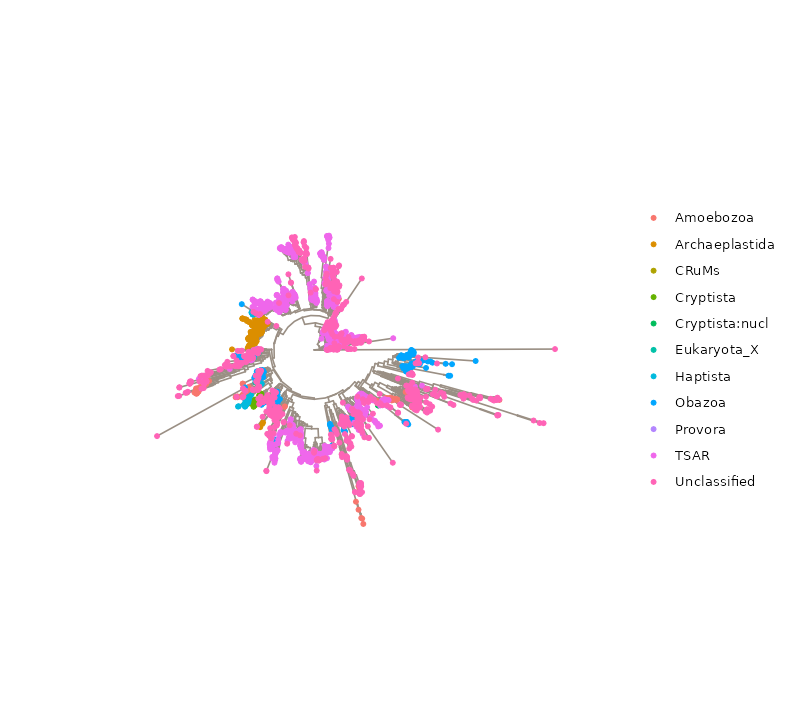

In [ ]:
step_start("n6", 6, 6, "Phylogenetic Tree")
settings <- list(`model` = "GTR")   # this step's settings from the canvas (tested program, pinned by the platform)
# Phylogenetic Tree: align the ASVs with MAFFT and infer an approximately
# maximum-likelihood tree with FastTree (GTR model), rooted at its midpoint.
if (!exists("ps") || is.null(ps) || is.null(phyloseq::refseq(ps, errorIfNULL = FALSE))) {
  step_skipped("n6", "run ASV Inference (DADA2) first: the tree is built from the ASV sequences")
} else if (phyloseq::ntaxa(ps) < 3) {
  step_skipped("n6", "fewer than three ASVs: there is no tree to build")
} else {
  fa <- tempfile(fileext = ".fasta"); aln <- tempfile(fileext = ".aln"); nwk <- tempfile(fileext = ".nwk")
  Biostrings::writeXStringSet(phyloseq::refseq(ps), fa)
  run_tool("mafft", c("--auto", "--thread", "2", "--quiet", fa), node_id = "n6", stdout_file = aln)
  run_tool("FastTree", c("-nt", if (identical(settings$model, "GTR")) "-gtr", "-gamma", "-quiet", aln), stdout_file = nwk)
  tree <- ape::read.tree(nwk)
  tree <- phangorn::midpoint(tree)
  ps <- phyloseq::merge_phyloseq(ps, phyloseq::phy_tree(tree))
  mb_tree <- tree
  ape::write.tree(tree, "artifacts/n6__asv_tree.nwk")
  metric("n6", "tips", ape::Ntip(tree))
  metric("n6", "alignment_columns", unique(Biostrings::width(Biostrings::readDNAStringSet(aln)))[1])
  tips <- data.frame(label = tree$tip.label)
  if (!is.null(phyloseq::tax_table(ps, errorIfNULL = FALSE))) {
    tt <- as.data.frame(as(phyloseq::tax_table(ps), "matrix"))
    tips$group <- ifelse(is.na(tt[tips$label, 2]), "Unclassified", tt[tips$label, 2])
  } else tips$group <- "ASV"
  p <- ggtree::`%<+%`(ggtree::ggtree(tree, layout = "circular", colour = "#9A8F84"), tips) +
    ggtree::geom_tippoint(ggplot2::aes(colour = group), size = 1.2) + ggplot2::labs(colour = NULL)
  save_fig(p, "n6__tree", width = 7.2, height = 6.4)
  emit_preview("n6", data.frame(asv = tree$tip.label, group = tips$group))
}
step_done("n6", 6, 6, "Phylogenetic Tree")

## BIOM Export

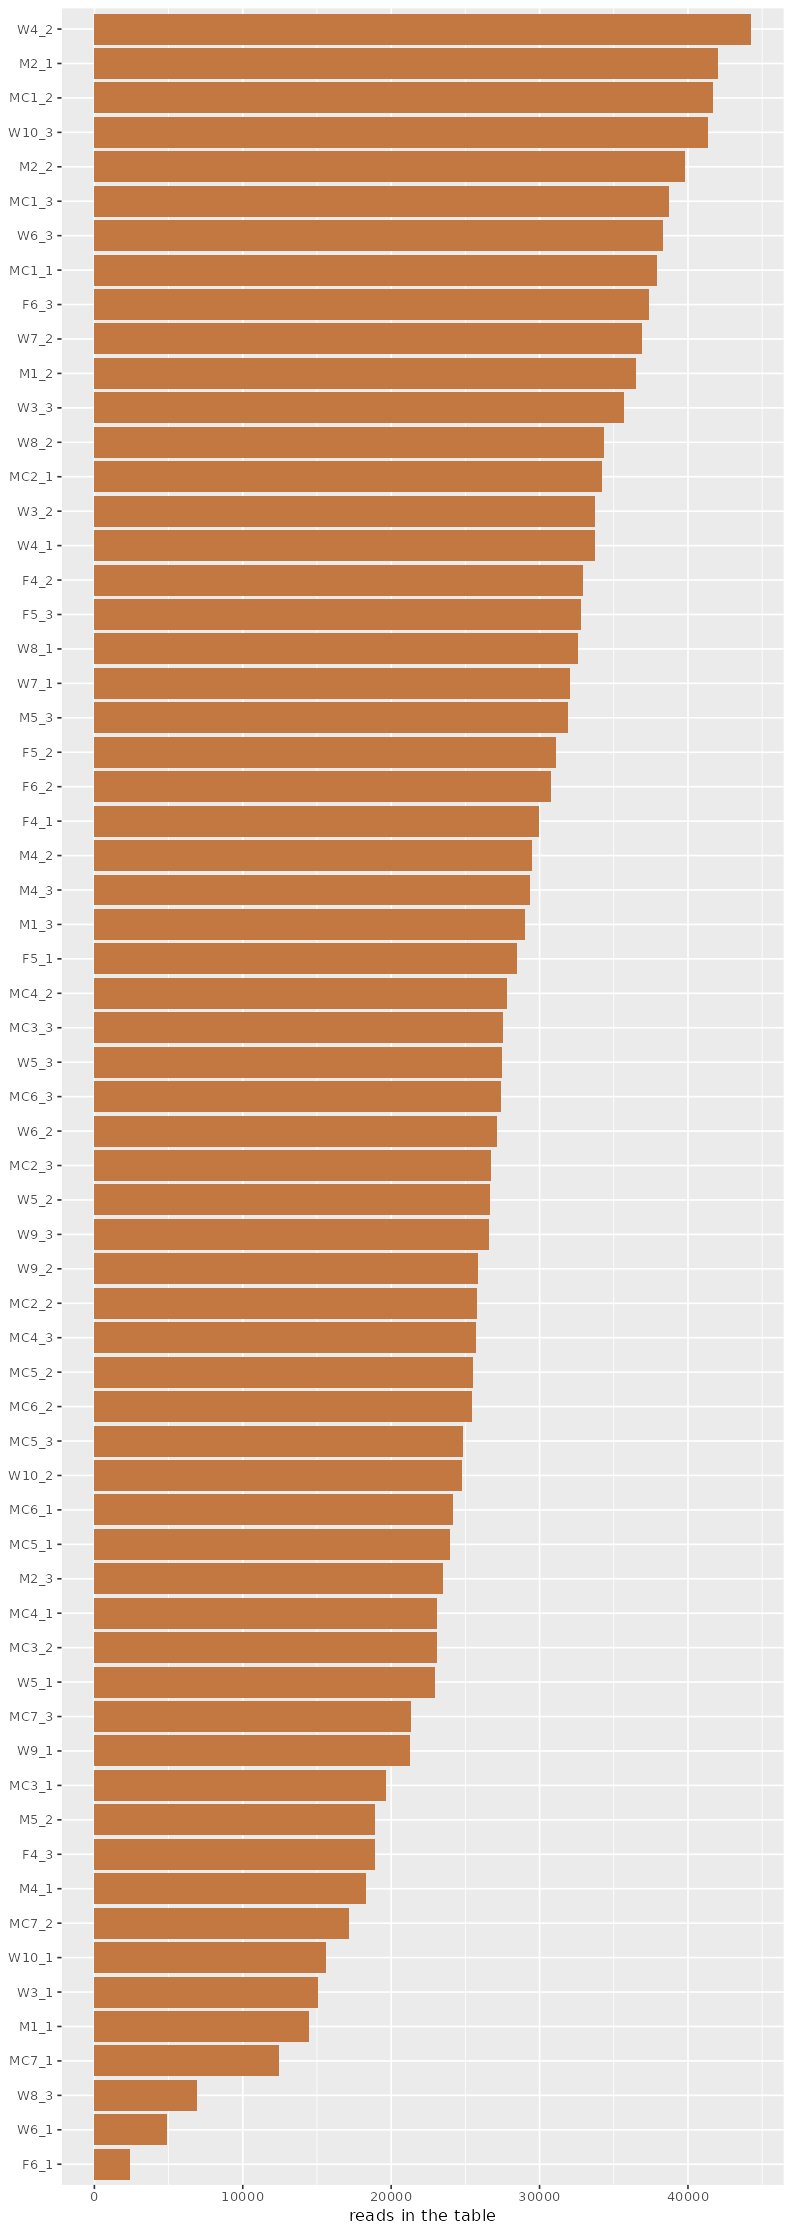

In [ ]:
step_start("n7", 9, 12, "BIOM Export")
settings <- list(`include_taxonomy` = TRUE, `include_samples` = TRUE)   # this step's settings from the canvas (tested program, pinned by the platform)
# BIOM Export: the feature table in the BIOM format every microbiome tool
# reads (QIIME 2, phyloseq, MicrobiomeAnalyst), with its taxonomy, sample
# table, sequences and tree beside it.
if (!exists("ps") || is.null(ps)) {
  step_skipped("n7", "there is no feature table yet: run ASV Inference (DADA2) or Import Feature Table first")
} else {
  otu <- as(phyloseq::otu_table(ps), "matrix")
  if (!phyloseq::taxa_are_rows(ps)) otu <- t(otu)
  tax <- if (!is.null(phyloseq::tax_table(ps, errorIfNULL = FALSE))) as.data.frame(as(phyloseq::tax_table(ps), "matrix")) else NULL
  sam <- if (!is.null(phyloseq::sample_data(ps, errorIfNULL = FALSE))) data.frame(phyloseq::sample_data(ps), check.names = FALSE) else NULL
  # BIOM 1.0 (JSON), written here rather than by biomformat::write_biom, which
  # puts each sample's metadata and each feature's taxonomy out as a bare array.
  # The Python biom reader behind QIIME 2 and PICRUSt2 refuses that ("Unable to
  # cast metadata"); the format wants a map per sample and {"taxonomy": [...]}.
  taxm <- if (!is.null(tax) && !isFALSE(settings$include_taxonomy)) as.matrix(tax) else NULL
  samm <- if (!is.null(sam) && !isFALSE(settings$include_samples)) sam else NULL
  nz <- which(otu != 0, arr.ind = TRUE)
  biom <- list(
    id = "n7 feature table", format = "Biological Observation Matrix 1.0.0", format_url = "http://biom-format.org",
    type = "OTU table", generated_by = "AlkhemYst-Ai", date = format(Sys.time(), "%Y-%m-%dT%H:%M:%S"),
    matrix_type = "sparse", matrix_element_type = if (all(otu == round(otu))) "int" else "float",
    shape = dim(otu), data = unname(cbind(nz[, 1] - 1, nz[, 2] - 1, otu[nz])),
    rows = lapply(rownames(otu), function(f) list(id = f, metadata = if (is.null(taxm)) NULL else
      list(taxonomy = I(ifelse(is.na(taxm[f, ]), "", unname(taxm[f, ])))))),
    columns = lapply(colnames(otu), function(s) list(id = s, metadata = if (is.null(samm)) NULL else
      lapply(as.list(samm[s, , drop = FALSE]), function(v) if (is.na(v)) NULL else as.character(v)))))
  jsonlite::write_json(biom, "artifacts/n7__feature_table.biom", auto_unbox = TRUE, null = "null", na = "null", digits = NA)
  data.table::fwrite(data.frame(feature = rownames(otu), otu, check.names = FALSE), "artifacts/n7__feature_table.csv")
  if (!is.null(tax)) data.table::fwrite(data.frame(feature = rownames(tax), tax, check.names = FALSE), "artifacts/n7__taxonomy.csv")
  if (!is.null(sam)) data.table::fwrite(sam, "artifacts/n7__sample_table.csv")
  if (!is.null(phyloseq::refseq(ps, errorIfNULL = FALSE))) Biostrings::writeXStringSet(phyloseq::refseq(ps), "artifacts/n7__sequences.fasta")
  if (!is.null(phyloseq::phy_tree(ps, errorIfNULL = FALSE))) ape::write.tree(phyloseq::phy_tree(ps), "artifacts/n7__tree.nwk")
  metric("n7", "features", nrow(otu))
  metric("n7", "samples", ncol(otu))
  metric("n7", "total_reads", sum(otu))
  emit_preview("n7", data.frame(feature = rownames(otu), otu[, seq_len(min(ncol(otu), 12)), drop = FALSE], check.names = FALSE))
  depth <- data.frame(sample = colnames(otu), reads = colSums(otu))
  save_fig(ggplot2::ggplot(depth, ggplot2::aes(stats::reorder(sample, reads), reads)) + ggplot2::geom_col(fill = "#C27840") +
    ggplot2::coord_flip() + ggplot2::labs(x = NULL, y = "reads in the table"), "n7__reads_per_sample")
}
step_done("n7", 9, 12, "BIOM Export")

## Taxonomy Composition

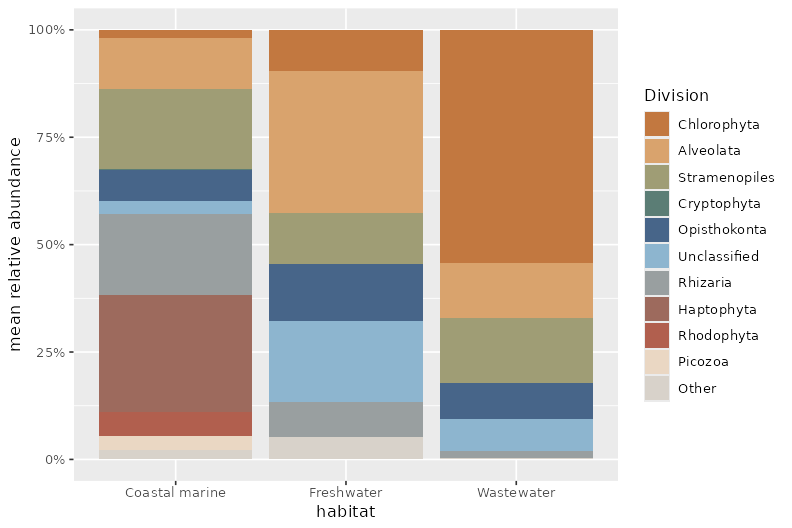

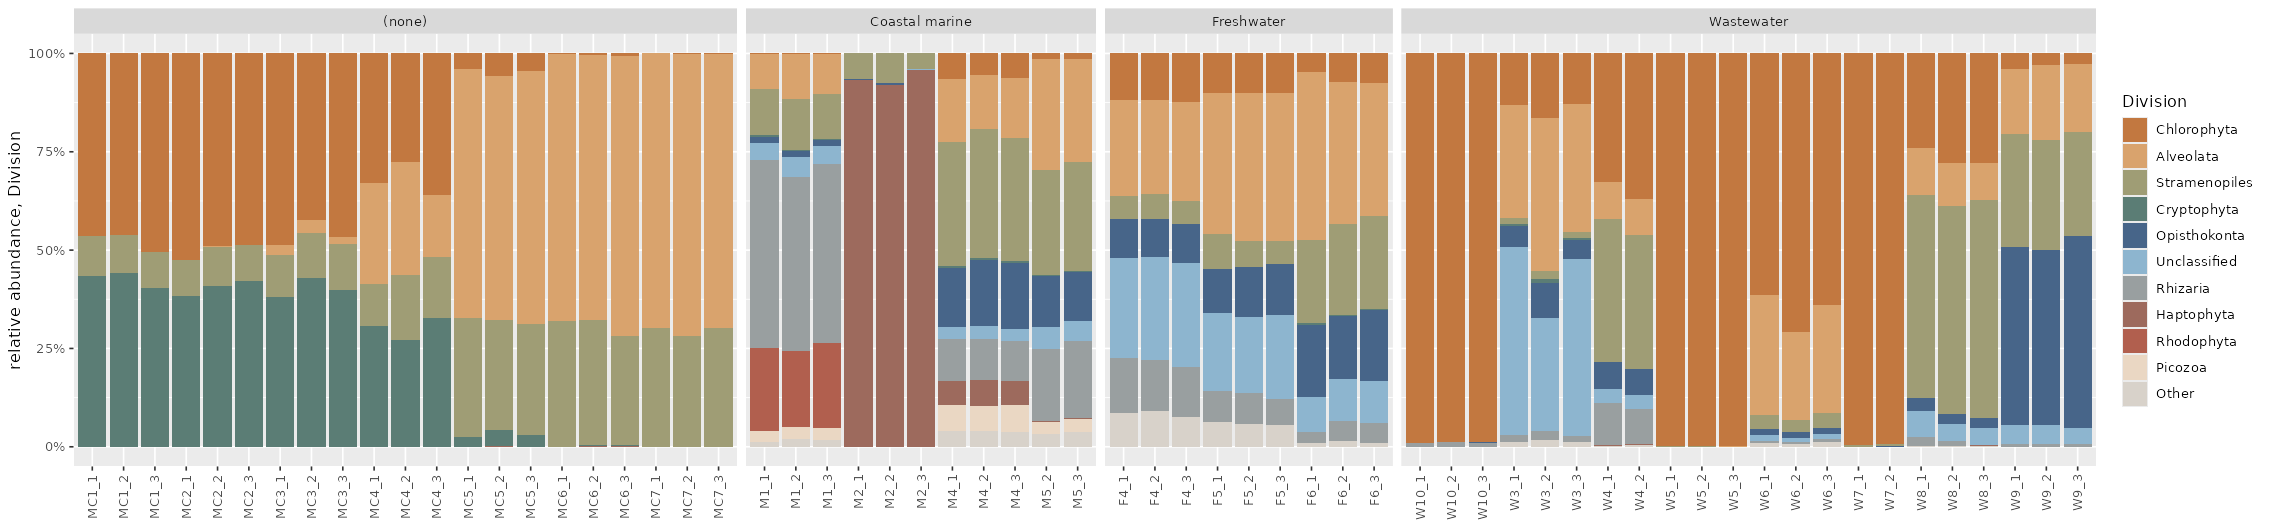

In [ ]:
step_start("n9", 10, 12, "Taxonomy Composition")
settings <- list(`rank` = "Division", `top_n` = 10, `group_col` = "habitat")   # this step's settings from the canvas (tested program, pinned by the platform)
# Taxonomy Composition: relative abundance at a chosen rank, the most abundant
# taxa named and the rest pooled, per sample and per group.
if (!exists("ps") || is.null(ps) || is.null(phyloseq::tax_table(ps, errorIfNULL = FALSE))) {
  step_skipped("n9", "the feature table has no taxonomy: run Taxonomy Assignment first")
} else {
  rank <- settings$rank
  if (!(rank %in% phyloseq::rank_names(ps))) rank <- phyloseq::rank_names(ps)[min(2, length(phyloseq::rank_names(ps)))]
  otu <- as(phyloseq::otu_table(ps), "matrix"); if (phyloseq::taxa_are_rows(ps)) otu <- t(otu)
  tax <- as(phyloseq::tax_table(ps), "matrix")[colnames(otu), rank]
  tax[is.na(tax) | tax == ""] <- "Unclassified"
  agg <- t(rowsum(t(otu), tax))
  rel <- agg / pmax(rowSums(agg), 1)
  top <- names(sort(colMeans(rel), decreasing = TRUE))[seq_len(min(as.integer(settings$top_n), ncol(rel)))]
  other <- setdiff(colnames(rel), top)
  shown <- cbind(rel[, top, drop = FALSE], Other = if (length(other)) rowSums(rel[, other, drop = FALSE]) else 0)
  long <- data.frame(sample = rep(rownames(shown), ncol(shown)), taxon = rep(colnames(shown), each = nrow(shown)),
                     abundance = as.vector(shown))
  long$taxon <- factor(long$taxon, levels = c(top, "Other"))
  grp <- settings$group_col
  sam <- if (!is.null(phyloseq::sample_data(ps, errorIfNULL = FALSE))) data.frame(phyloseq::sample_data(ps), check.names = FALSE) else NULL
  has_grp <- !is.null(sam) && length(grp) && nzchar(grp) && grp %in% names(sam)
  # The group goes into the table BEFORE the plot is made: ggplot keeps a copy
  # of its data, so a column added afterwards is not there to facet by, and
  # every run with a group column drew a blank figure by sample.
  if (has_grp) {
    long$group <- as.character(sam[long$sample, grp]); long$group[is.na(long$group) | long$group == ""] <- "(none)"
  }
  pal <- grDevices::colorRampPalette(c("#C27840", "#E0B07A", "#6B8F71", "#3D5A80", "#98C1D9", "#9A8F84", "#A13D2D", "#EAD7C3"))(length(top))
  pal <- c(stats::setNames(pal, top), Other = "#D8D2CA")
  p <- ggplot2::ggplot(long, ggplot2::aes(sample, abundance, fill = taxon)) + ggplot2::geom_col(width = 0.9) +
    ggplot2::scale_fill_manual(values = pal) + ggplot2::scale_y_continuous(labels = function(x) paste0(100 * x, "%")) +
    ggplot2::labs(x = NULL, y = paste("relative abundance,", rank), fill = rank) +
    ggplot2::theme(axis.text.x = ggplot2::element_text(angle = 90, hjust = 1, vjust = 0.5))
  if (has_grp) {
    p <- p + ggplot2::facet_grid(~group, scales = "free_x", space = "free_x")
    # a sample with no group (a mock community, a blank) is drawn per sample
    # above and left out of the group means, where it would read as a group
    means <- stats::aggregate(abundance ~ group + taxon, data = long[long$group != "(none)", ], FUN = mean)
    save_fig(ggplot2::ggplot(means, ggplot2::aes(group, abundance, fill = taxon)) + ggplot2::geom_col() +
      ggplot2::scale_fill_manual(values = pal) + ggplot2::scale_y_continuous(labels = function(x) paste0(100 * x, "%")) +
      ggplot2::labs(x = grp, y = "mean relative abundance", fill = rank), "n9__composition_by_group")
  }
  save_fig(p, "n9__composition_by_sample", width = max(7.2, 0.28 * nrow(shown) + 3))
  metric("n9", "rank", rank)
  metric("n9", "taxa_at_rank", ncol(rel))
  metric("n9", "top_taxon", top[1])
  metric("n9", "top_taxon_mean_pct", round(100 * mean(rel[, top[1]]), 1))
  data.table::fwrite(data.frame(sample = rownames(rel), rel, check.names = FALSE), "artifacts/n9__relative_abundance.csv")
  emit_preview("n9", data.frame(taxon = colnames(shown), mean_pct = round(100 * colMeans(shown), 2)))
}
step_done("n9", 10, 12, "Taxonomy Composition")

## Alpha Diversity

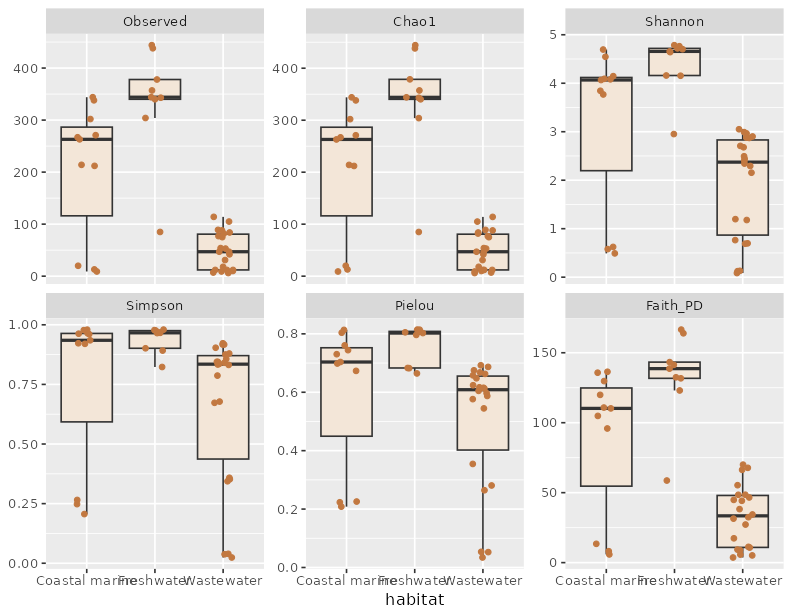

In [ ]:
step_start("n10", 11, 12, "Alpha Diversity")
settings <- list(`group_col` = "habitat", `rarefy` = FALSE, `rarefy_depth` = 0, `seed` = 1)   # this step's settings from the canvas (tested program, pinned by the platform)
# Alpha Diversity: richness and evenness within each sample, compared between groups.
if (!exists("ps") || is.null(ps)) {
  step_skipped("n10", "there is no feature table yet")
} else {
  x <- ps
  if (isTRUE(settings$rarefy)) {
    depth <- if (as.numeric(settings$rarefy_depth) > 0) as.numeric(settings$rarefy_depth) else min(phyloseq::sample_sums(x))
    x <- phyloseq::rarefy_even_depth(x, sample.size = depth, rngseed = as.integer(settings$seed), verbose = FALSE)
    metric("n10", "rarefied_to", depth)
  }
  est <- phyloseq::estimate_richness(x, measures = c("Observed", "Chao1", "Shannon", "Simpson"))
  rownames(est) <- phyloseq::sample_names(x)
  est$Pielou <- est$Shannon / log(pmax(est$Observed, 2))
  tree <- phyloseq::phy_tree(x, errorIfNULL = FALSE)
  if (!is.null(tree)) {
    otu <- as(phyloseq::otu_table(x), "matrix"); if (phyloseq::taxa_are_rows(x)) otu <- t(otu)
    est$Faith_PD <- picante::pd(otu, tree, include.root = FALSE)[rownames(est), "PD"]
  } else metric("n10", "faith_pd", "not computed: no phylogenetic tree (run Phylogenetic Tree first)")
  keep <- intersect(c("Observed", "Chao1", "Shannon", "Simpson", "Pielou", "Faith_PD"), names(est))
  est <- est[, keep, drop = FALSE]
  table_out <- data.frame(sample = rownames(est), round(est, 4), check.names = FALSE)
  grp <- settings$group_col
  sam <- if (!is.null(phyloseq::sample_data(x, errorIfNULL = FALSE))) data.frame(phyloseq::sample_data(x), check.names = FALSE) else NULL
  if (!is.null(sam) && length(grp) && nzchar(grp) && grp %in% names(sam)) {
    g <- as.character(sam[rownames(est), grp]); ok <- !is.na(g) & g != ""
    table_out[[grp]] <- g
    long <- data.frame(metric = rep(keep, each = sum(ok)), group = rep(g[ok], length(keep)),
                       value = unlist(lapply(keep, function(k) est[ok, k])))
    long$metric <- factor(long$metric, levels = keep)
    if (length(unique(g[ok])) >= 2) {
      for (k in keep) {
        kt <- stats::kruskal.test(est[ok, k], factor(g[ok]))
        metric("n10", paste0(k, "_p"), signif(kt$p.value, 3))
      }
      if (length(unique(g[ok])) > 2) {
        pw <- stats::pairwise.wilcox.test(est[ok, "Shannon"], g[ok], p.adjust.method = "BH")
        metric("n10", "Shannon_pairwise_min_p", signif(min(pw$p.value, na.rm = TRUE), 3))
      }
    }
    save_fig(ggplot2::ggplot(long, ggplot2::aes(group, value)) + ggplot2::geom_boxplot(outlier.shape = NA, fill = "#F3E6D8") +
      ggplot2::geom_jitter(width = 0.15, colour = "#C27840", size = 1.4) + ggplot2::facet_wrap(~metric, scales = "free_y") +
      ggplot2::labs(x = grp, y = NULL), "n10__alpha_by_group", height = 5.6)
  } else {
    long <- data.frame(metric = rep(keep, each = nrow(est)), value = unlist(est[keep]))
    save_fig(ggplot2::ggplot(long, ggplot2::aes(value)) + ggplot2::geom_histogram(bins = 15, fill = "#C27840") +
      ggplot2::facet_wrap(~metric, scales = "free"), "n10__alpha_distributions")
  }
  for (k in keep) metric("n10", paste0(k, "_median"), round(stats::median(est[[k]]), 3))
  emit_preview("n10", table_out)
  data.table::fwrite(table_out, "artifacts/n10__alpha_diversity.csv")
}
step_done("n10", 11, 12, "Alpha Diversity")

## Beta Diversity

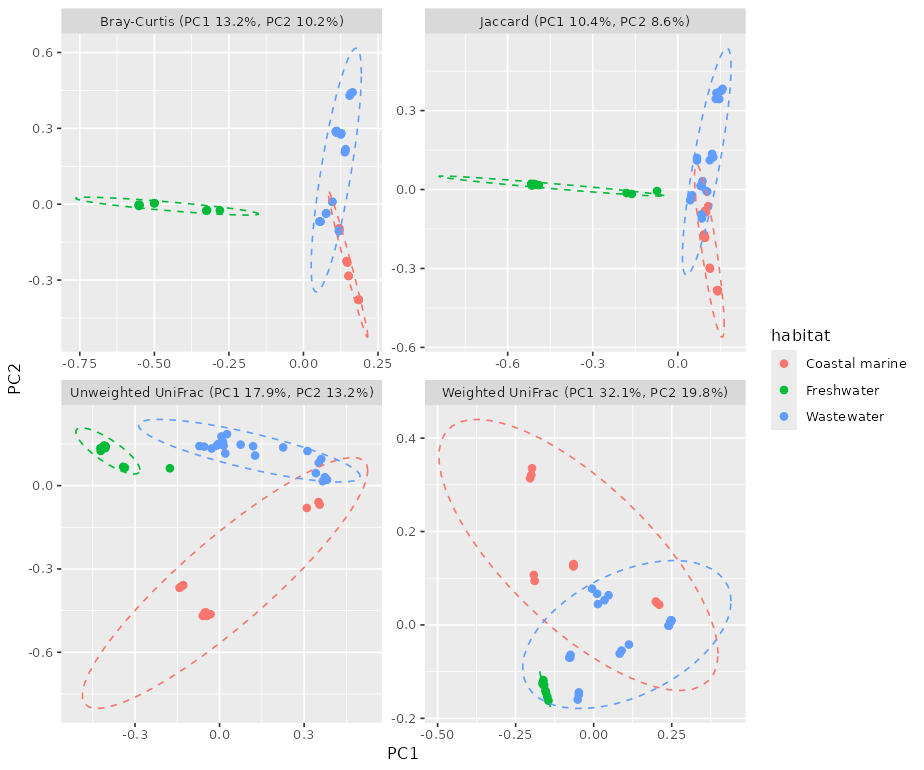

In [ ]:
step_start("n11", 12, 12, "Beta Diversity")
settings <- list(`distances` = c("Bray-Curtis", "Jaccard", "Unweighted UniFrac", "Weighted UniFrac"), `group_col` = "habitat", `permutations` = 999, `seed` = 1)   # this step's settings from the canvas (tested program, pinned by the platform)
# Beta Diversity: how different the samples are from each other, drawn as a
# PCoA for each distance and tested between groups with PERMANOVA.
if (!exists("ps") || is.null(ps)) {
  step_skipped("n11", "there is no feature table yet")
} else {
  x <- phyloseq::prune_samples(phyloseq::sample_sums(ps) > 0, ps)
  grp <- settings$group_col
  sam <- if (!is.null(phyloseq::sample_data(x, errorIfNULL = FALSE))) data.frame(phyloseq::sample_data(x), check.names = FALSE) else NULL
  has_grp <- !is.null(sam) && length(grp) && nzchar(grp) && grp %in% names(sam)
  # Compared by group, the ordination shows the samples the test compares. A
  # sample with no group (a mock community, a blank) is left out, and named:
  # kept, the MiSeq SOP mock took the whole first axis of the Bray-Curtis PCoA.
  if (has_grp) {
    gv <- as.character(sam[phyloseq::sample_names(x), grp])
    out <- phyloseq::sample_names(x)[is.na(gv) | gv == ""]
    if (length(out) && length(out) < phyloseq::nsamples(x) - 3) {
      x <- phyloseq::prune_samples(setdiff(phyloseq::sample_names(x), out), x)
      metric("n11", "samples_without_group_left_out", paste(out, collapse = ", "))
    }
  }
  rel <- phyloseq::transform_sample_counts(x, function(v) v / sum(v))
  otu <- as(phyloseq::otu_table(rel), "matrix"); if (phyloseq::taxa_are_rows(rel)) otu <- t(otu)
  tree <- phyloseq::phy_tree(x, errorIfNULL = FALSE)
  wanted <- trimws(unlist(strsplit(as.character(unlist(settings$distances)), ",")))
  dists <- list()
  if ("Bray-Curtis" %in% wanted) dists[["Bray-Curtis"]] <- vegan::vegdist(otu, "bray")
  if ("Jaccard" %in% wanted) dists[["Jaccard"]] <- vegan::vegdist(otu > 0, "jaccard", binary = TRUE)
  if (!is.null(tree) && "Unweighted UniFrac" %in% wanted) dists[["Unweighted UniFrac"]] <- phyloseq::UniFrac(x, weighted = FALSE)
  if (!is.null(tree) && "Weighted UniFrac" %in% wanted) dists[["Weighted UniFrac"]] <- phyloseq::UniFrac(x, weighted = TRUE)
  if (is.null(tree) && any(grepl("UniFrac", wanted))) metric("n11", "unifrac", "not computed: no phylogenetic tree (run Phylogenetic Tree first)")
  pts <- list(); tests <- list()
  for (nm in names(dists)) {
    d <- dists[[nm]]
    pc <- stats::cmdscale(d, k = 2, eig = TRUE)
    ev <- pc$eig[pc$eig > 0]; pct <- round(100 * pc$eig[1:2] / sum(ev), 1)
    pts[[nm]] <- data.frame(sample = rownames(pc$points), PC1 = pc$points[, 1], PC2 = pc$points[, 2],
                            distance = sprintf("%s (PC1 %s%%, PC2 %s%%)", nm, pct[1], pct[2]))
    if (has_grp) {
      g <- as.character(sam[labels(d), grp]); ok <- !is.na(g) & g != ""
      if (length(unique(g[ok])) >= 2 && sum(ok) >= 4) {
        dd <- stats::as.dist(as.matrix(d)[ok, ok])
        md <- data.frame(group = factor(g[ok]))
        set.seed(as.integer(settings$seed))
        a <- vegan::adonis2(dd ~ group, data = md, permutations = as.integer(settings$permutations))
        disp <- vegan::betadisper(dd, md$group)
        bd <- vegan::permutest(disp, permutations = as.integer(settings$permutations))
        # which group varies more: its samples' mean distance to the group centroid
        spread <- tapply(disp$distances, disp$group, mean)
        spread_txt <- paste(sprintf("%s %.3f", names(spread), spread), collapse = "; ")
        tests[[nm]] <- data.frame(distance = nm, R2 = round(a$R2[1], 4), F = round(a$F[1], 3), p = a$`Pr(>F)`[1],
                                  dispersion_p = bd$tab$`Pr(>F)`[1], spread_by_group = spread_txt)
        key <- gsub("[^a-z]+", "_", tolower(nm))
        metric("n11", paste0(key, "_permanova_R2"), round(a$R2[1], 4))
        metric("n11", paste0(key, "_permanova_p"), a$`Pr(>F)`[1])
        metric("n11", paste0(key, "_dispersion_p"), bd$tab$`Pr(>F)`[1])
        metric("n11", paste0(key, "_spread_by_group"), spread_txt)
      }
    }
  }
  allp <- do.call(rbind, pts)
  if (has_grp) { allp$group <- as.character(sam[allp$sample, grp]); allp$group[is.na(allp$group) | allp$group == ""] <- "(none)" } else allp$group <- "all"
  p <- ggplot2::ggplot(allp, ggplot2::aes(PC1, PC2, colour = group)) + ggplot2::geom_point(size = 2) +
    ggplot2::facet_wrap(~distance, scales = "free") + ggplot2::labs(colour = if (has_grp) grp else NULL)
  if (has_grp) p <- p + ggplot2::stat_ellipse(data = allp[allp$group != "(none)", ], level = 0.95, linetype = "dashed", show.legend = FALSE)
  save_fig(p, "n11__pcoa", width = 8.4, height = if (length(dists) > 2) 7 else 4.2)
  if (length(tests)) {
    tt <- do.call(rbind, tests); emit_preview("n11", tt)
    data.table::fwrite(tt, "artifacts/n11__permanova.csv")
  } else emit_preview("n11", allp)
  metric("n11", "distances", paste(names(dists), collapse = ", "))
}
step_done("n11", 12, 12, "Beta Diversity")

## Finalize

In [ ]:
local({
  out <- as.list(METRICS)
  if (length(out) == 0) {
    # Said plainly rather than written as an empty object. A run that measured
    # nothing is nearly always a run where the steps wrote somewhere else, and
    # an empty metrics.json looks identical to a pipeline that had nothing to
    # measure.
    message("no metrics were recorded by any step")
  }
  jsonlite::write_json(out, "artifacts/metrics.json", auto_unbox = TRUE, null = "null")
})
print("pipeline finished")

## Run output

In [ ]:
# captured stdout (tail)

[1] "[[step]] n0 start 1/12 \342\226\266 Dataset"
[1] "archive data/bradley2016_18S_V4.zip: 126 read files, sample table samples.csv (63 rows)"
[1] "[[step]] n0 done 1/12 \342\234\223 Dataset"
[1] "[[step]] n1 start 1/3 \342\226\266 Read Quality Report"
[1] "[[step]] n1 done 1/3 \342\234\223 Read Quality Report"
[1] "[[step]] n2 start 2/3 \342\226\266 Primer Trimming (Cutadapt)"
[1] "[[step]] n2 done 2/3 \342\234\223 Primer Trimming (Cutadapt)"
[1] "[[step]] n3 start 3/3 \342\226\266 Filter & Trim Reads"
[1] "[[step]] n3 done 3/3 \342\234\223 Filter & Trim Reads"
[1] "[[step]] n4 start 4/5 \342\226\266 ASV Inference (DADA2)"
100303600 total bases in 501518 reads from 16 samples will be used for learning the error rates.
100385760 total bases in 418274 reads from 13 samples will be used for learning the error rates.
[1] "[[step]] n4 done 4/5 \342\234\223 ASV Inference (DADA2)"
[1] "[[step]] n15 start 5/5 \342\226\266 Mock Community Check"
[1] "[[step]] n15 done 5/5 \342\234\223 Mock Com

## Metrics
```json
{
  "n15::strains_recovered": 10,
  "n11::weighted_unifrac_permanova_R2": 0.3277,
  "n7::samples": 63,
  "n11::unweighted_unifrac_spread_by_group": "Coastal marine 0.522; Freshwater 0.336; Wastewater 0.554",
  "n1::paired_end": true,
  "n1::samples": 63,
  "n10::Simpson_median": 0.833,
  "n10::Shannon_median": 2.155,
  "n4::asvs": 2900,
  "n11::weighted_unifrac_permanova_p": 0.001,
  "n10::Faith_PD_p": 0,
  "n1::median_reads_per_sample": 40233,
  "n1::min_reads_per_sample": 3695,
  "n4::samples": 63,
  "n0::rows": 63,
  "n11::samples_without_group_left_out": "MC1_1, MC1_2, MC1_3, MC2_1, MC2_2, MC2_3, MC3_1, MC3_2, MC3_3, MC4_1, MC4_2, MC4_3, MC5_1, MC5_2, MC5_3, MC6_1, MC6_2, MC6_3, MC7_1, MC7_2, MC7_3",
  "n3::reads_kept": 1855084,
  "n11::jaccard_dispersion_p": 0.001,
  "n2::reads_in": 2445599,
  "n10::Faith_PD_median": 17.376,
  "n10::Chao1_median": 20,
  "n5::method": "IDTAXA (DECIPHER), the classifier PR2 trained",
  "n9::top_taxon": "Chlorophyta",
  "n5::classified_family_pct": 57.2,
  "n3::reads_kept_pct": 75.9,
  "n10::Pielou_median": 0.673,
  "n6::alignment_columns": 1368,
  "n15::asvs_shared_by_strains": 0,
  "n6::tips": 2900,
  "n15::samples_with_a_strain_missing": 18,
  "n11::weighted_unifrac_spread_by_group": "Coastal marine 0.278; Freshwater 0.134; Wastewater 0.223",
  "n0::read_files": 126,
  "n15::strains_missing": "Prymnesium_parvum, Isochrysis_galbana",
  "n11::unweighted_unifrac_dispersion_p": 0.001,
  "n11::jaccard_spread_by_group": "Coastal marine 0.612; Freshwater 0.513; Wastewater 0.650",
  "n5::classified_order_pct": 61.3,
  "n3::trunc_len_reverse": 240,
  "n5::reference": "PR2 5.0.0 trained IDTAXA classifier (DECIPHER), 18S",
  "n11::unweighted_unifrac_permanova_R2": 0.2614,
  "n10::Observed_median": 20,
  "n15::expected_strains": 12,
  "n11::unweighted_unifrac_permanova_p": 0.001,
  "n5::classified_domain_pct": 81,
  "n5::classified_division_pct": 72.9,
  "n0::columns": 6,
  "n15::expected_sequences": 12,
  "n9::top_taxon_mean_pct": 29.2,
  "n7::total_reads": 1720407,
  "n4::chimeric_reads_pct": 1.11,
  "n15::reads_not_exact_pct": 0.3,
  "n15::asvs_exact_match": 10,
  "n11::distances": "Bray-Curtis, Jaccard, Unweighted UniFrac, Weighted UniFrac",
  "n11::bray_curtis_dispersion_p": 0.001,
  "n5::classified_class_pct": 65.2,
  "n2::primers_absent": true,
  "n15::asvs_exact_over_partial_reference": 0,
  "n3::truncation": "from the quality profile (lower quartile above Q25), lengthened to keep a 20-base overlap over the 420-base amplicon",
  "n11::jaccard_permanova_R2": 0.1687,
  "n7::features": 2900,
  "n10::Simpson_p": 0.001,
  "n2::reads_out": 2445599,
  "n3::trunc_len_forward": 200,
  "n1::fastqc_modules_failed": 556,
  "n4::reads_retained_pct": 70.3,
  "n10::Shannon_pairwise_min_p": 2.08e-06,
  "n11::jaccard_permanova_p": 0.001,
  "n10::Pielou_p": 0.0002,
  "n5::classified_subdivision_pct": 71.4,
  "n1::fastqc_modules_warned": 64,
  "n15::mock_sample": "21 samples (MC1_1, MC1_2, MC1_3, MC2_1)",
  "n4::reads_non_chimeric": 1720407,
  "n10::Shannon_p": 0,
  "n2::primer_found_pct": 0.2,
  "n5::classified_species_pct": 32.3,
  "n10::Chao1_p": 0,
  "n15::samples_with_an_unexpected_strain": 2,
  "n9::rank": "Division",
  "n15::mock_samples": 21,
  "n11::weighted_unifrac_dispersion_p": 0.001,
  "n5::classified_supergroup_pct": 74.1,
  "n15::asvs_not_expected": 23,
  "n5::classified_genus_pct": 43.9,
  "n10::Observed_p": 0,
  "n11::bray_curtis_permanova_p": 0.001,
  "n11::bray_curtis_permanova_R2": 0.2185,
  "n3::reads_in": 2445599,
  "n15::asvs_in_mock": 40,
  "n11::bray_curtis_spread_by_group": "Coastal marine 0.588; Freshwater 0.425; Wastewater 0.647",
  "n9::taxa_at_rank": 24
}
```